# 07 — Paper Results: Chapter 4 (Results and Discussion)

Three-pillar evaluation framework for hybrid bias correction of satellite precipitation:

1. **Adjusting Values** (mean & magnitude): Relative Bias, Std. Dev. Ratio
2. **Aligning Distributions** (statistical shape): KS p-value, Wet-Day Freq. Ratio, Mean Wet-Day Precip Ratio
3. **Preserving Extremes** (tail accuracy): Q95 Ratio, Q99 Ratio

Plus **Event Detection** (POD, CSI, FAR) and **Temporal Skill** (Pearson Corr, RMSE, NSE).

All tables and figures for the paper are generated here.

In [1]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists("/content/drive"):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4 cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 136.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.3 MB/s eta 0:00:00


In [3]:
# -- Setup --------------------------------------------------------------------
import os
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
})

# -- Project root & config ---------------------------------------------------
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = '/content/drive/MyDrive/hybrid-bias-correction'
# project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.config import initialize_config
initialize_config(os.path.join(project_root, 'config.yml'))

# -- Constants ----------------------------------------------------------------
METHODS = ['ls', 'lseqm', 'lseqmdl']
METHOD_LABELS = ['LS', 'LSEQM', 'LSEQM+DL']
DEKAD_MAP = {1: '01', 2: '11', 3: '21'}
ALL_PERIODS = [(m, d) for m in range(1, 13) for d in [1, 2, 3]]
WET_MONTHS = [10, 11, 12, 1, 2, 3]
DRY_MONTHS = [4, 5, 6, 7, 8, 9]

# -- Three-pillar metrics -----------------------------------------------------
PILLAR_METRICS = {
    'Value Adjustment': {
        'relative_bias': ('Relative Bias', 0),
        'stdev_ratio': ('Std. Dev. Ratio', 1.0),
    },
    'Distribution Alignment': {
        'ks_pvalue': ('KS p-value (%)', 100),
        'fpd_ratio': ('Wet-Day Freq. Ratio', 1.0),
        'mdwp_ratio': ('Mean Wet-Day Precip Ratio', 1.0),
    },
    'Extreme Preservation': {
        'p95_ratio': ('Q95 Ratio', 1.0),
        'p99_ratio': ('Q99 Ratio', 1.0),
    },
    'Event Detection': {
        'pod': ('POD', 1.0),
        'csi': ('CSI', 1.0),
        'far': ('FAR', 0),
    },
}

TEMPORAL_METRICS = {
    'pearson_correlation': ('Pearson Corr', 1.0),
    'rmse': ('RMSE (mm/day)', 0),
    'nse': ('NSE', 1.0),
}

# -- Path helpers -------------------------------------------------------------
OUTPUT_DIR = os.path.join(project_root, 'data', 'output')
FIG_DIR = os.path.join(OUTPUT_DIR, 'figures', 'paper')
os.makedirs(FIG_DIR, exist_ok=True)


def metrics_path(method, month, dekad):
    """Return path to metricssd NetCDF for given method/period."""
    dd = DEKAD_MAP[dekad]
    fname = f'idn_cli_metricssd_cpc_imergl_{method}_month{month:02d}_dekad{dd}.nc4'
    return os.path.join(OUTPUT_DIR, f'metrics_{method}', fname)


def quality_path(method, month, dekad):
    """Return path to qualitysd NetCDF for given method/period."""
    dd = DEKAD_MAP[dekad]
    fname = f'idn_cli_qualitysd_cpc_imergl_{method}_month{month:02d}_dekad{dd}.nc4'
    return os.path.join(OUTPUT_DIR, f'quality_{method}', fname)


def station_val_path(method, month, dekad):
    """Return path to station validation CSV."""
    dd = DEKAD_MAP[dekad]
    fname = f'station_validation_{method}_month{month:02d}_dekad{dd}.csv'
    return os.path.join(OUTPUT_DIR, 'station_validation', fname)


def multi_threshold_path(method, month, dekad):
    """Return path to multi-threshold summary CSV."""
    dd = DEKAD_MAP[dekad]
    fname = f'multi_threshold_summary_{method}_month{month:02d}_dekad{dd}.csv'
    return os.path.join(OUTPUT_DIR, 'station_validation', fname)


def save_fig(fig, name, dpi=200):
    """Save figure to paper figures directory."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')


def compute_spatial_medians(ds, var_names):
    """Compute spatial median (over lat/lon) for each variable."""
    result = {}
    for v in var_names:
        if v in ds.data_vars:
            vals = ds[v].values.ravel()
            vals = vals[np.isfinite(vals)]
            result[v] = np.median(vals) if len(vals) > 0 else np.nan
        else:
            result[v] = np.nan
    return result


def compute_ratio_medians(ds, pairs):
    """Compute spatial median of test/ref ratio for each pair.

    Parameters
    ----------
    ds : xarray.Dataset
    pairs : dict  {ratio_name: (test_var, ref_var)}

    Returns
    -------
    dict : {ratio_name: median_ratio}
    """
    result = {}
    for name, (test_var, ref_var) in pairs.items():
        if test_var in ds.data_vars and ref_var in ds.data_vars:
            test_vals = ds[test_var].values
            ref_vals = ds[ref_var].values
            mask = np.isfinite(test_vals) & np.isfinite(ref_vals) & (ref_vals > 0)
            if np.any(mask):
                ratio = test_vals[mask] / ref_vals[mask]
                result[name] = np.median(ratio)
            else:
                result[name] = np.nan
        else:
            result[name] = np.nan
    return result


print(f'Project root: {project_root}')
print(f'Output dir:   {OUTPUT_DIR}')
print(f'Figure dir:   {FIG_DIR}')
print(f'Periods:      {len(ALL_PERIODS)} dekads')
print('Setup complete.')

2026-03-04 15:03:56,427 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config.yml
2026-03-04 15:03:56,779 - INFO - Configuration initialized successfully.
2026-03-04 15:03:56,780 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-03-04 15:03:56,781 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/input
2026-03-04 15:03:56,782 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/output
2026-03-04 15:03:56,783 - INFO -   Interactive mode: True
Project root: /content/drive/MyDrive/hybrid-bias-correction
Output dir:   /content/drive/MyDrive/hybrid-bias-correction/data/output
Figure dir:   /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper
Periods:      36 dekads
Setup complete.


## Step 1 — Data Inventory

Count available files per method to confirm completeness before analysis.

In [4]:
# -- Data inventory -----------------------------------------------------------
print('File inventory (expected: 36 per method)\n')
print(f'{"Category":<25} {"LS":>5} {"LSEQM":>7} {"LSEQM+DL":>10}')
print('-' * 50)

for category, path_fn in [
    ('Metrics (metricssd)', metrics_path),
    ('Quality (qualitysd)', quality_path),
    ('Station validation', station_val_path),
    ('Multi-threshold', multi_threshold_path),
]:
    counts = []
    for method in METHODS:
        n = sum(1 for m, d in ALL_PERIODS if os.path.exists(path_fn(method, m, d)))
        counts.append(n)
    print(f'{category:<25} {counts[0]:>5} {counts[1]:>7} {counts[2]:>10}')

# Confidence mask
conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
print(f'\nConfidence mask: {"found" if os.path.exists(conf_mask_path) else "MISSING"}')

File inventory (expected: 36 per method)

Category                     LS   LSEQM   LSEQM+DL
--------------------------------------------------
Metrics (metricssd)          36      36         36
Quality (qualitysd)          36      36         36
Station validation           36      36         36
Multi-threshold              36      36         36

Confidence mask: found


## Step 2 — Table 4: Three-Pillar Domain-Wide Evaluation

For each method, load all 36 dekad metricssd files, compute spatial medians,
then average across dekads. Results organized by three pillars plus event
detection and temporal skill.

In [5]:
# -- Table 4: Domain-wide three-pillar evaluation ----------------------------

# Direct metrics to extract from each file
DIRECT_VARS = [
    'relative_bias', 'stdev_ratio', 'ks_pvalue',
    'pod', 'csi', 'far',
    'pearson_correlation', 'rmse', 'nse',
]

# Ratio pairs: name -> (test_var, ref_var)
RATIO_PAIRS = {
    'fpd_ratio': ('fpd_test', 'fpd_ref'),
    'mdwp_ratio': ('mdwp_test', 'mdwp_ref'),
    'p95_ratio': ('p95_test', 'p95_ref'),
    'p99_ratio': ('p99_test', 'p99_ref'),
}

# Collect results: {method: {metric: [values_per_period]}}
table4_data = {m: {v: [] for v in DIRECT_VARS + list(RATIO_PAIRS.keys())}
               for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)

        # Direct spatial medians
        medians = compute_spatial_medians(ds, DIRECT_VARS)
        for v in DIRECT_VARS:
            if np.isfinite(medians.get(v, np.nan)):
                table4_data[method][v].append(medians[v])

        # Ratio spatial medians
        ratio_medians = compute_ratio_medians(ds, RATIO_PAIRS)
        for v in RATIO_PAIRS:
            if np.isfinite(ratio_medians.get(v, np.nan)):
                table4_data[method][v].append(ratio_medians[v])

        ds.close()

# Compute means across periods
table4_means = {}
for method in METHODS:
    table4_means[method] = {}
    for v in DIRECT_VARS + list(RATIO_PAIRS.keys()):
        vals = table4_data[method][v]
        table4_means[method][v] = np.mean(vals) if len(vals) > 0 else np.nan

# -- Print Table 4 -----------------------------------------------------------
print('=' * 72)
print('TABLE 4: Domain-Wide Evaluation (36-dekad mean of spatial medians)')
print('Reference: CPC-UNI')
print('=' * 72)
print(f'{"Metric":<30} {"Ideal":>6} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
print('-' * 72)

for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    print(f'\n  {pillar_name}')
    print(f'  {"-" * 68}')
    for key, (label, ideal) in pillar_metrics.items():
        vals = [table4_means[m].get(key, np.nan) for m in METHODS]
        ideal_str = f'{ideal}'
        print(f'  {label:<28} {ideal_str:>6}'
              f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print(f'\n  Temporal Skill (acknowledged limitation)')
print(f'  {"-" * 68}')
for key, (label, ideal) in TEMPORAL_METRICS.items():
    vals = [table4_means[m].get(key, np.nan) for m in METHODS]
    ideal_str = f'{ideal}'
    print(f'  {label:<28} {ideal_str:>6}'
          f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 72)

TABLE 4: Domain-Wide Evaluation (36-dekad mean of spatial medians)
Reference: CPC-UNI
Metric                          Ideal         LS      LSEQM   LSEQM+DL
------------------------------------------------------------------------

  Value Adjustment
  --------------------------------------------------------------------
  Relative Bias                     0     0.0000    -0.0089    -0.0125
  Std. Dev. Ratio                 1.0     0.9707     1.0166     1.0080

  Distribution Alignment
  --------------------------------------------------------------------
  KS p-value (%)                  100    50.5905    54.2755    53.6575
  Wet-Day Freq. Ratio             1.0     1.0397     0.9630     0.9633
  Mean Wet-Day Precip Ratio       1.0     0.9611     1.0417     1.0361

  Extreme Preservation
  --------------------------------------------------------------------
  Q95 Ratio                       1.0     1.0205     0.9530     0.9530
  Q99 Ratio                       1.0     0.9612     1.0104  

## Step 3 — Stratified Analysis by Confidence Mask

Split domain into station-covered (confidence >= 0.5) and station-sparse
(confidence < 0.5) regions. Compare three-pillar metrics to assess whether
DL refinement helps differentially.

In [6]:
# -- Stratified analysis by confidence mask -----------------------------------
conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
conf_ds = xr.open_dataset(conf_mask_path, decode_timedelta=False)
conf_arr = conf_ds['confidence'].values  # shape: (lat, lon)
conf_ds.close()

# Masks
mask_covered = conf_arr >= 0.5
mask_sparse = (conf_arr < 0.5) & np.isfinite(conf_arr)
print(f'Station-covered pixels (C >= 0.5): {np.sum(mask_covered)}')
print(f'Station-sparse pixels  (C <  0.5): {np.sum(mask_sparse)}')


def compute_masked_medians(ds, var_names, spatial_mask):
    """Compute median of variable values within spatial_mask."""
    result = {}
    for v in var_names:
        if v in ds.data_vars:
            arr = ds[v].values
            if arr.shape == spatial_mask.shape:
                vals = arr[spatial_mask & np.isfinite(arr)]
                result[v] = np.median(vals) if len(vals) > 0 else np.nan
            else:
                result[v] = np.nan
        else:
            result[v] = np.nan
    return result


def compute_masked_ratio_medians(ds, pairs, spatial_mask):
    """Compute median of test/ref ratio within spatial_mask."""
    result = {}
    for name, (test_var, ref_var) in pairs.items():
        if test_var in ds.data_vars and ref_var in ds.data_vars:
            t = ds[test_var].values
            r = ds[ref_var].values
            if t.shape == spatial_mask.shape:
                ok = spatial_mask & np.isfinite(t) & np.isfinite(r) & (r > 0)
                if np.any(ok):
                    result[name] = np.median(t[ok] / r[ok])
                else:
                    result[name] = np.nan
            else:
                result[name] = np.nan
        else:
            result[name] = np.nan
    return result


# Collect stratified data
strat_labels = ['Covered (C>=0.5)', 'Sparse (C<0.5)']
strat_masks = [mask_covered, mask_sparse]
strat_data = {}  # {region: {method: {metric: mean}}}

all_metric_keys = DIRECT_VARS + list(RATIO_PAIRS.keys())

for region_label, spatial_mask in zip(strat_labels, strat_masks):
    strat_data[region_label] = {m: {v: [] for v in all_metric_keys} for m in METHODS}
    for method in METHODS:
        for month, dekad in ALL_PERIODS:
            fpath = metrics_path(method, month, dekad)
            if not os.path.exists(fpath):
                continue
            ds = xr.open_dataset(fpath, decode_timedelta=False)
            medians = compute_masked_medians(ds, DIRECT_VARS, spatial_mask)
            ratio_m = compute_masked_ratio_medians(ds, RATIO_PAIRS, spatial_mask)
            medians.update(ratio_m)
            for v in all_metric_keys:
                val = medians.get(v, np.nan)
                if np.isfinite(val):
                    strat_data[region_label][method][v].append(val)
            ds.close()

# Print stratified comparison
print('\n' + '=' * 80)
print('STRATIFIED ANALYSIS: Station-Covered vs. Station-Sparse')
print('=' * 80)

# Show key metrics only for readability
key_metrics = [
    ('relative_bias', 'Relative Bias', 0),
    ('stdev_ratio', 'Std. Dev. Ratio', 1.0),
    ('ks_pvalue', 'KS p-value (%)', 100),
    ('p99_ratio', 'Q99 Ratio', 1.0),
    ('csi', 'CSI', 1.0),
    ('pearson_correlation', 'Pearson Corr', 1.0),
    ('rmse', 'RMSE (mm/day)', 0),
]

for region_label in strat_labels:
    print(f'\n  {region_label}')
    print(f'  {"Metric":<25} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
    print(f'  {"-" * 57}')
    for key, label, ideal in key_metrics:
        vals = []
        for m in METHODS:
            v_list = strat_data[region_label][m][key]
            vals.append(np.mean(v_list) if len(v_list) > 0 else np.nan)
        print(f'  {label:<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 80)

Station-covered pixels (C >= 0.5): 59
Station-sparse pixels  (C <  0.5): 78772

STRATIFIED ANALYSIS: Station-Covered vs. Station-Sparse

  Covered (C>=0.5)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0001    -0.0839    -0.1210
  Std. Dev. Ratio               1.0380     0.9894     0.8986
  KS p-value (%)               40.5299    41.5539    36.8601
  Q99 Ratio                     0.9717     0.9237     0.9177
  CSI                           0.6028     0.5833     0.5854
  Pearson Corr                  0.5415     0.5458     0.5618
  RMSE (mm/day)                 8.4569     8.2414     7.7619

  Sparse (C<0.5)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0000    -0.0087    -0.0122
  Std. Dev. Ratio               0.9705     1.0167     1.0082
  KS p-value (%)               50.6

## Step 4 — Table 5: Percentile Fidelity

Extract reference and test percentiles (P25 through P99), compute spatial
medians, and report percentage error for each method.

In [7]:
# -- Table 5: Percentile fidelity ---------------------------------------------
PCTL_VARS = ['p25', 'p50', 'p75', 'p90', 'p95', 'p99']
PCTL_LABELS = ['P25', 'P50', 'P75', 'P90', 'P95', 'P99']

# Collect: {method: {pctl: {'ref': [values], 'test': [values]}}}
table5_data = {m: {p: {'ref': [], 'test': []} for p in PCTL_VARS}
               for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        for p in PCTL_VARS:
            ref_var = f'{p}_ref'
            test_var = f'{p}_test'
            if ref_var in ds.data_vars and test_var in ds.data_vars:
                ref_vals = ds[ref_var].values.ravel()
                test_vals = ds[test_var].values.ravel()
                ref_fin = ref_vals[np.isfinite(ref_vals)]
                test_fin = test_vals[np.isfinite(test_vals)]
                if len(ref_fin) > 0:
                    table5_data[method][p]['ref'].append(np.median(ref_fin))
                if len(test_fin) > 0:
                    table5_data[method][p]['test'].append(np.median(test_fin))
        ds.close()

# Print Table 5
print('=' * 90)
print('TABLE 5: Percentile Fidelity (domain-wide spatial median, 36-dekad mean)')
print('=' * 90)
print(f'{"Pctl":<6} {"CPC Ref":>8}', end='')
for label in METHOD_LABELS:
    print(f' {label:>10} {"% Err":>8}', end='')
print()
print('-' * 90)

for p, plabel in zip(PCTL_VARS, PCTL_LABELS):
    # Reference is same across methods (from CPC), take from LS
    ref_mean = np.mean(table5_data['ls'][p]['ref']) if table5_data['ls'][p]['ref'] else np.nan
    print(f'{plabel:<6} {ref_mean:>8.2f}', end='')
    for method in METHODS:
        test_mean = (np.mean(table5_data[method][p]['test'])
                     if table5_data[method][p]['test'] else np.nan)
        if np.isfinite(ref_mean) and ref_mean != 0:
            pct_err = 100.0 * (test_mean - ref_mean) / ref_mean
        else:
            pct_err = np.nan
        print(f' {test_mean:>10.2f} {pct_err:>7.1f}%', end='')
    print()

print('=' * 90)

TABLE 5: Percentile Fidelity (domain-wide spatial median, 36-dekad mean)
Pctl    CPC Ref         LS    % Err      LSEQM    % Err   LSEQM+DL    % Err
------------------------------------------------------------------------------------------
P25        9.08       8.92    -1.8%      10.22    12.5%      10.22    12.5%
P50        0.12       0.07   -43.2%       0.12     3.2%       0.12     3.2%
P75        0.27       0.44    62.6%       0.22   -19.6%       0.22   -19.6%
P90        2.22       2.62    18.0%       1.91   -13.8%       1.91   -13.8%
P95        8.64       8.84     2.4%       8.27    -4.2%       8.27    -4.2%
P99       20.22      19.47    -3.7%      20.66     2.2%      20.60     1.9%


## Step 5 — Table 6: Cross-Reference Evaluation Matrix

Simplified 5-column table showing key metrics with CPC-UNI reference
(and IMERG-F reference if available).

In [8]:
# -- Table 6: Cross-reference evaluation matrix --------------------------------

# Key metrics for the simplified table
TABLE6_KEYS = ['relative_bias', 'stdev_ratio', 'ks_pvalue', 'p99_ratio', 'csi']
TABLE6_LABELS = ['Rel. Bias', 'Stdev Ratio', 'KS p-val (%)', 'Q99 Ratio', 'CSI']

# Use already-computed table4_means for CPC reference
print('=' * 75)
print('TABLE 6: Cross-Reference Evaluation Matrix')
print('=' * 75)
print(f'{"Reference / Method":<22}', end='')
for label in TABLE6_LABELS:
    print(f' {label:>12}', end='')
print()
print('-' * 75)

print('\n  CPC-UNI reference:')
for method, mlabel in zip(METHODS, METHOD_LABELS):
    print(f'  {mlabel:<20}', end='')
    for key in TABLE6_KEYS:
        val = table4_means[method].get(key, np.nan)
        print(f' {val:>12.4f}', end='')
    print()

# Check if IMERG-F metrics exist
imergf_metrics_dir = os.path.join(OUTPUT_DIR, 'metrics_imergf')
if os.path.exists(imergf_metrics_dir):
    print('\n  IMERG-F reference:')
    print('  (IMERG-F cross-reference data available)')
else:
    print('\n  IMERG-F reference: not available (single-reference evaluation)')

print('\n' + '=' * 75)

TABLE 6: Cross-Reference Evaluation Matrix
Reference / Method        Rel. Bias  Stdev Ratio KS p-val (%)    Q99 Ratio          CSI
---------------------------------------------------------------------------

  CPC-UNI reference:
  LS                         0.0000       0.9707      50.5905       0.9612       0.5890
  LSEQM                     -0.0089       1.0166      54.2755       1.0104       0.5684
  LSEQM+DL                  -0.0125       1.0080      53.6575       1.0090       0.5684

  IMERG-F reference: not available (single-reference evaluation)



## Step 6 — Figure 4: CQI Spatial Maps

Average continuous quality index (CQI) across all 36 dekads for each method.
Three-panel map showing spatial distribution over Indonesia.

ls: loaded 36 periods, CQI range [0.427, 0.681]
lseqm: loaded 36 periods, CQI range [0.283, 0.679]
lseqmdl: loaded 36 periods, CQI range [0.283, 0.681]
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig04_cqi_spatial.png


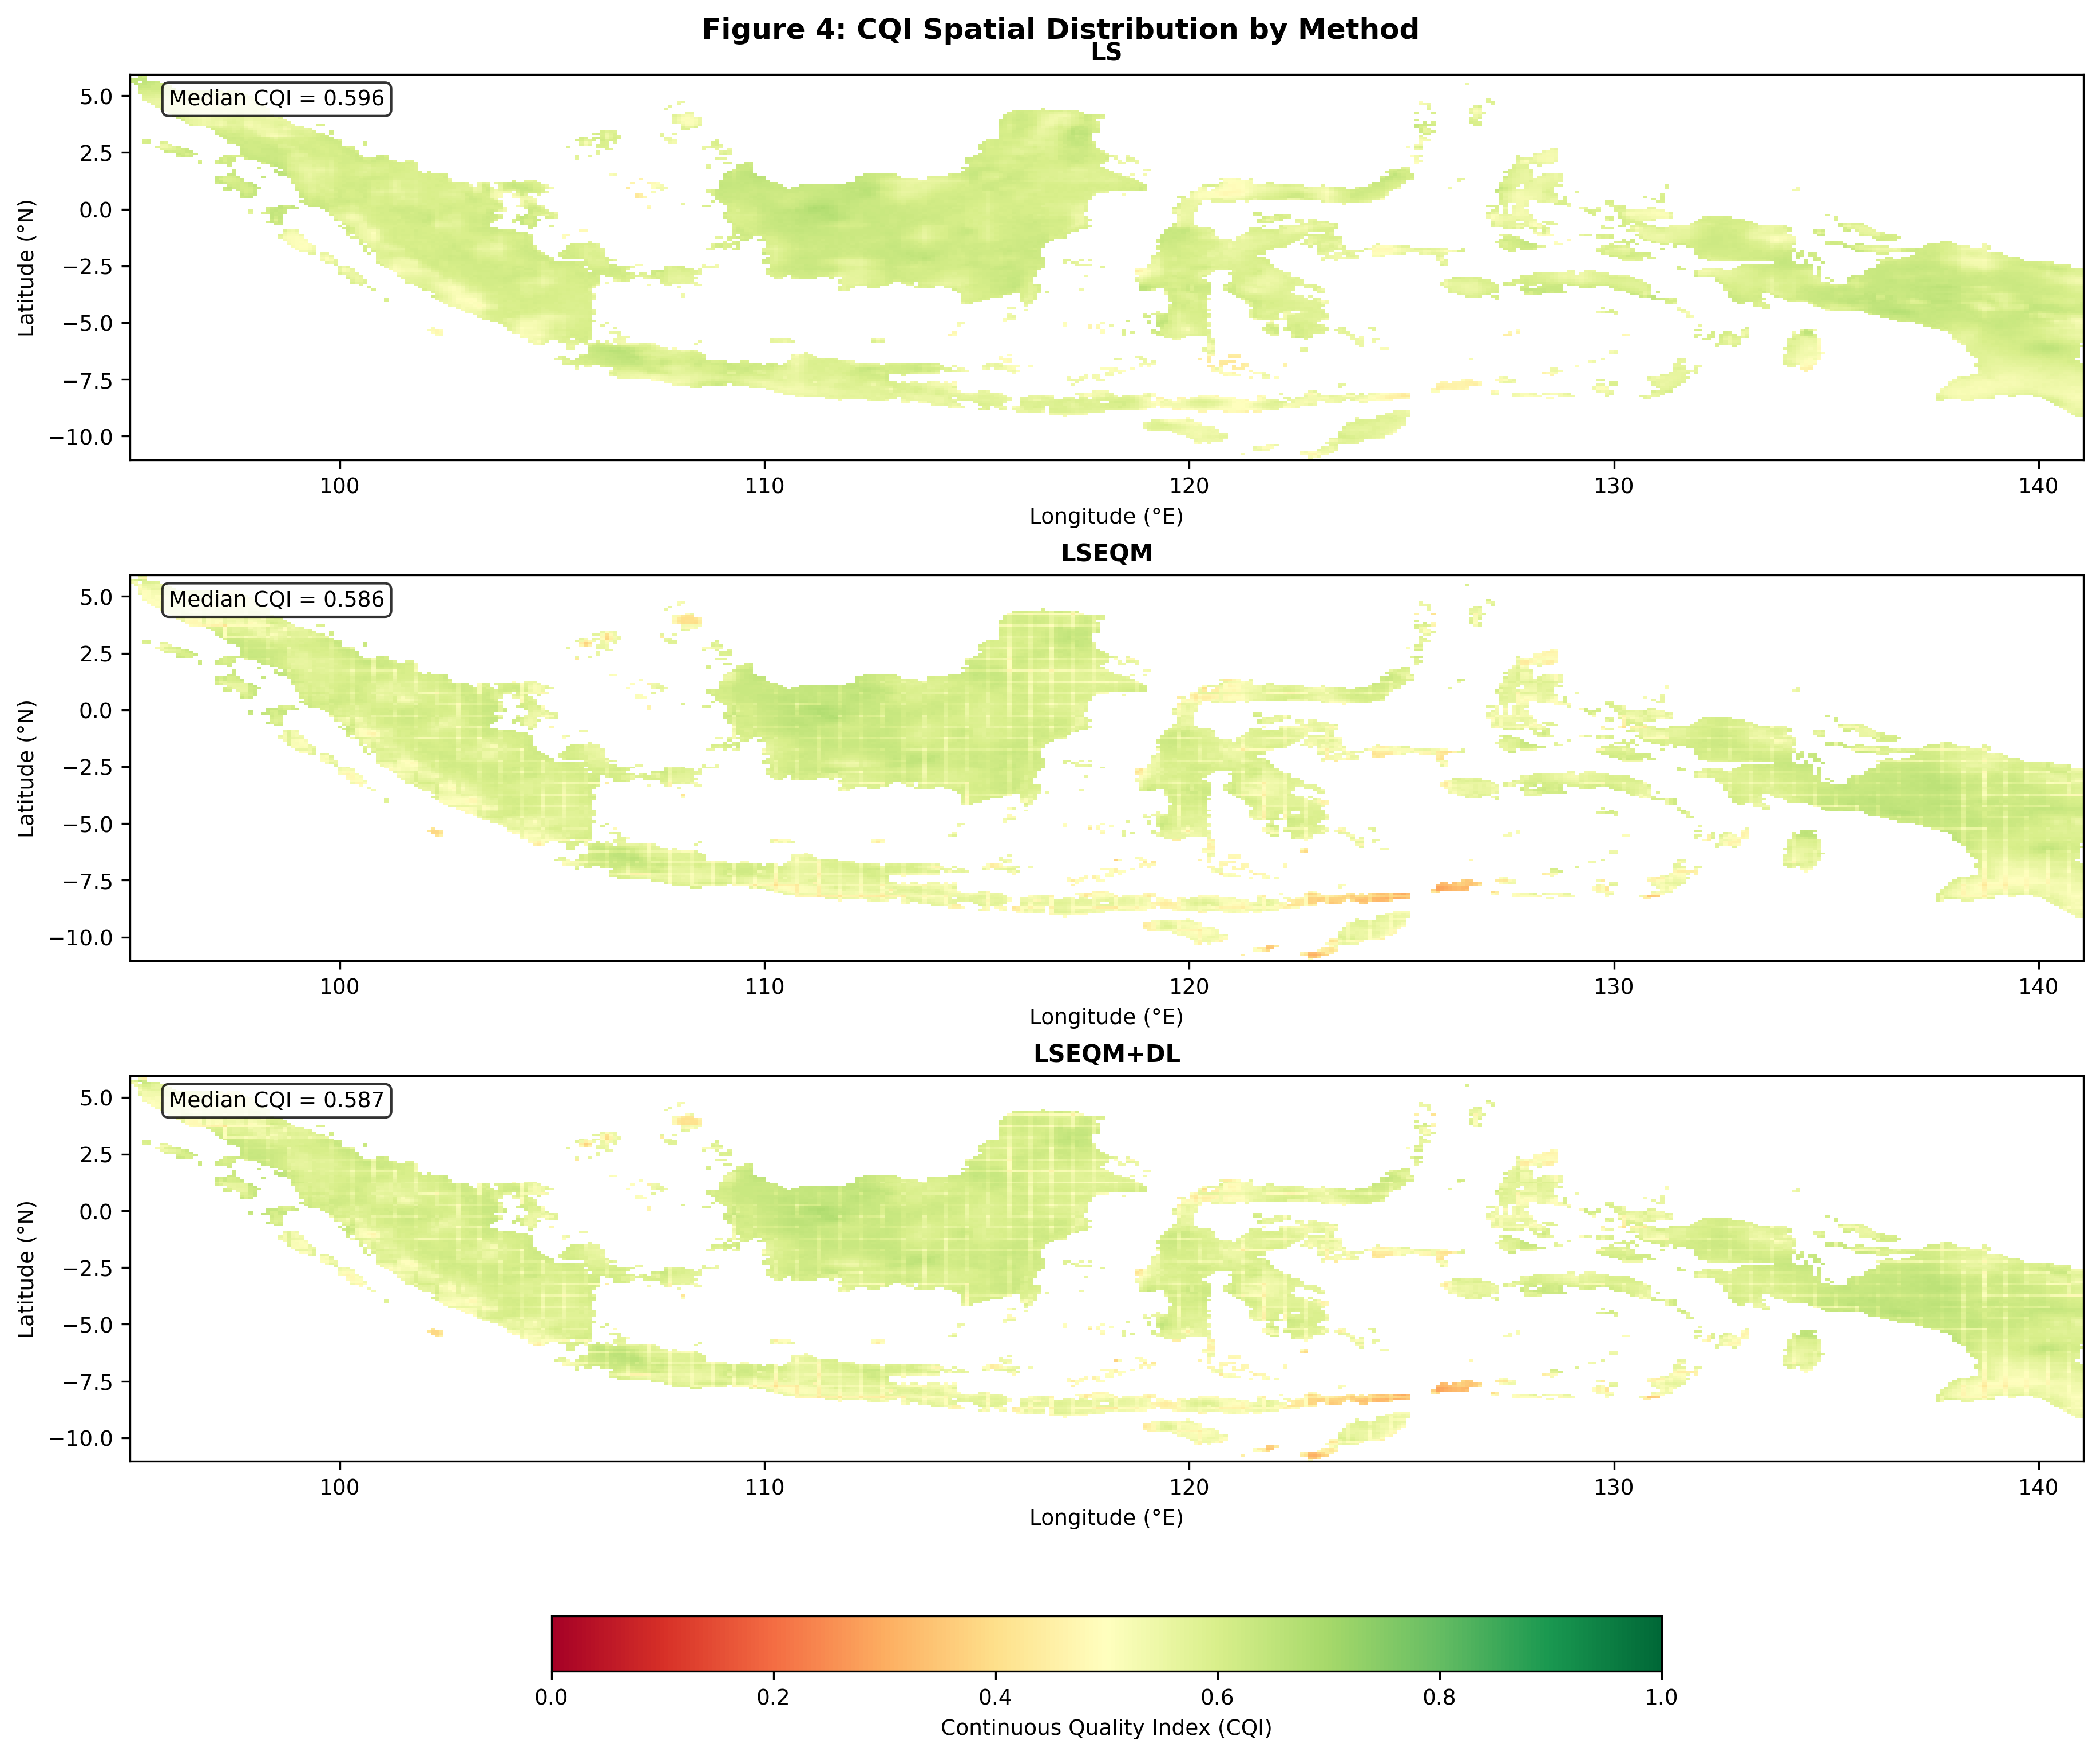

In [9]:
# -- Figure 4: CQI spatial maps -----------------------------------------------

# Load and average CQI across all periods
cqi_maps = {}  # method -> 2D array (lat, lon)
lat_coords = None
lon_coords = None

for method in METHODS:
    cqi_stack = []
    for month, dekad in ALL_PERIODS:
        fpath = quality_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        if 'continuous_quality' in ds.data_vars:
            cqi_stack.append(ds['continuous_quality'].values)
            if lat_coords is None:
                lat_coords = ds['lat'].values
                lon_coords = ds['lon'].values
        ds.close()
    if cqi_stack:
        cqi_maps[method] = np.nanmean(np.stack(cqi_stack, axis=0), axis=0)
        print(f'{method}: loaded {len(cqi_stack)} periods, '
              f'CQI range [{np.nanmin(cqi_maps[method]):.3f}, '
              f'{np.nanmax(cqi_maps[method]):.3f}]')

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

extent = [lon_coords.min(), lon_coords.max(),
          lat_coords.min(), lat_coords.max()]

for ax, method, mlabel in zip(axes, METHODS, METHOD_LABELS):
    im = ax.imshow(
        cqi_maps[method],
        extent=extent,
        origin='lower',
        cmap='RdYlGn',
        vmin=0, vmax=1,
        aspect='auto',
        interpolation='nearest',
    )
    ax.set_title(f'{mlabel}', fontweight='bold')
    ax.set_xlabel('Longitude (\u00b0E)')
    ax.set_ylabel('Latitude (\u00b0N)')

    # Domain median annotation
    med = np.nanmedian(cqi_maps[method])
    ax.text(0.02, 0.92, f'Median CQI = {med:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                     fraction=0.04, pad=0.06, shrink=0.6)
cbar.set_label('Continuous Quality Index (CQI)')

fig.suptitle('Figure 4: CQI Spatial Distribution by Method',
             fontsize=12, fontweight='bold', y=1.01)

save_fig(fig, 'fig04_cqi_spatial.png')
plt.show()

## Step 7 — Figure 5: CQI Improvement

Panel (a): CQI difference map (LSEQM+DL minus LS).
Panel (b): Categorical classification of LSEQM+DL (Excellent/Good/Fair/Poor).

Excellent: 0.0% (0 pixels)
Good: 36.2% (7014 pixels)
Fair: 63.1% (12239 pixels)
Poor: 0.7% (140 pixels)
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig05_cqi_improvement.png


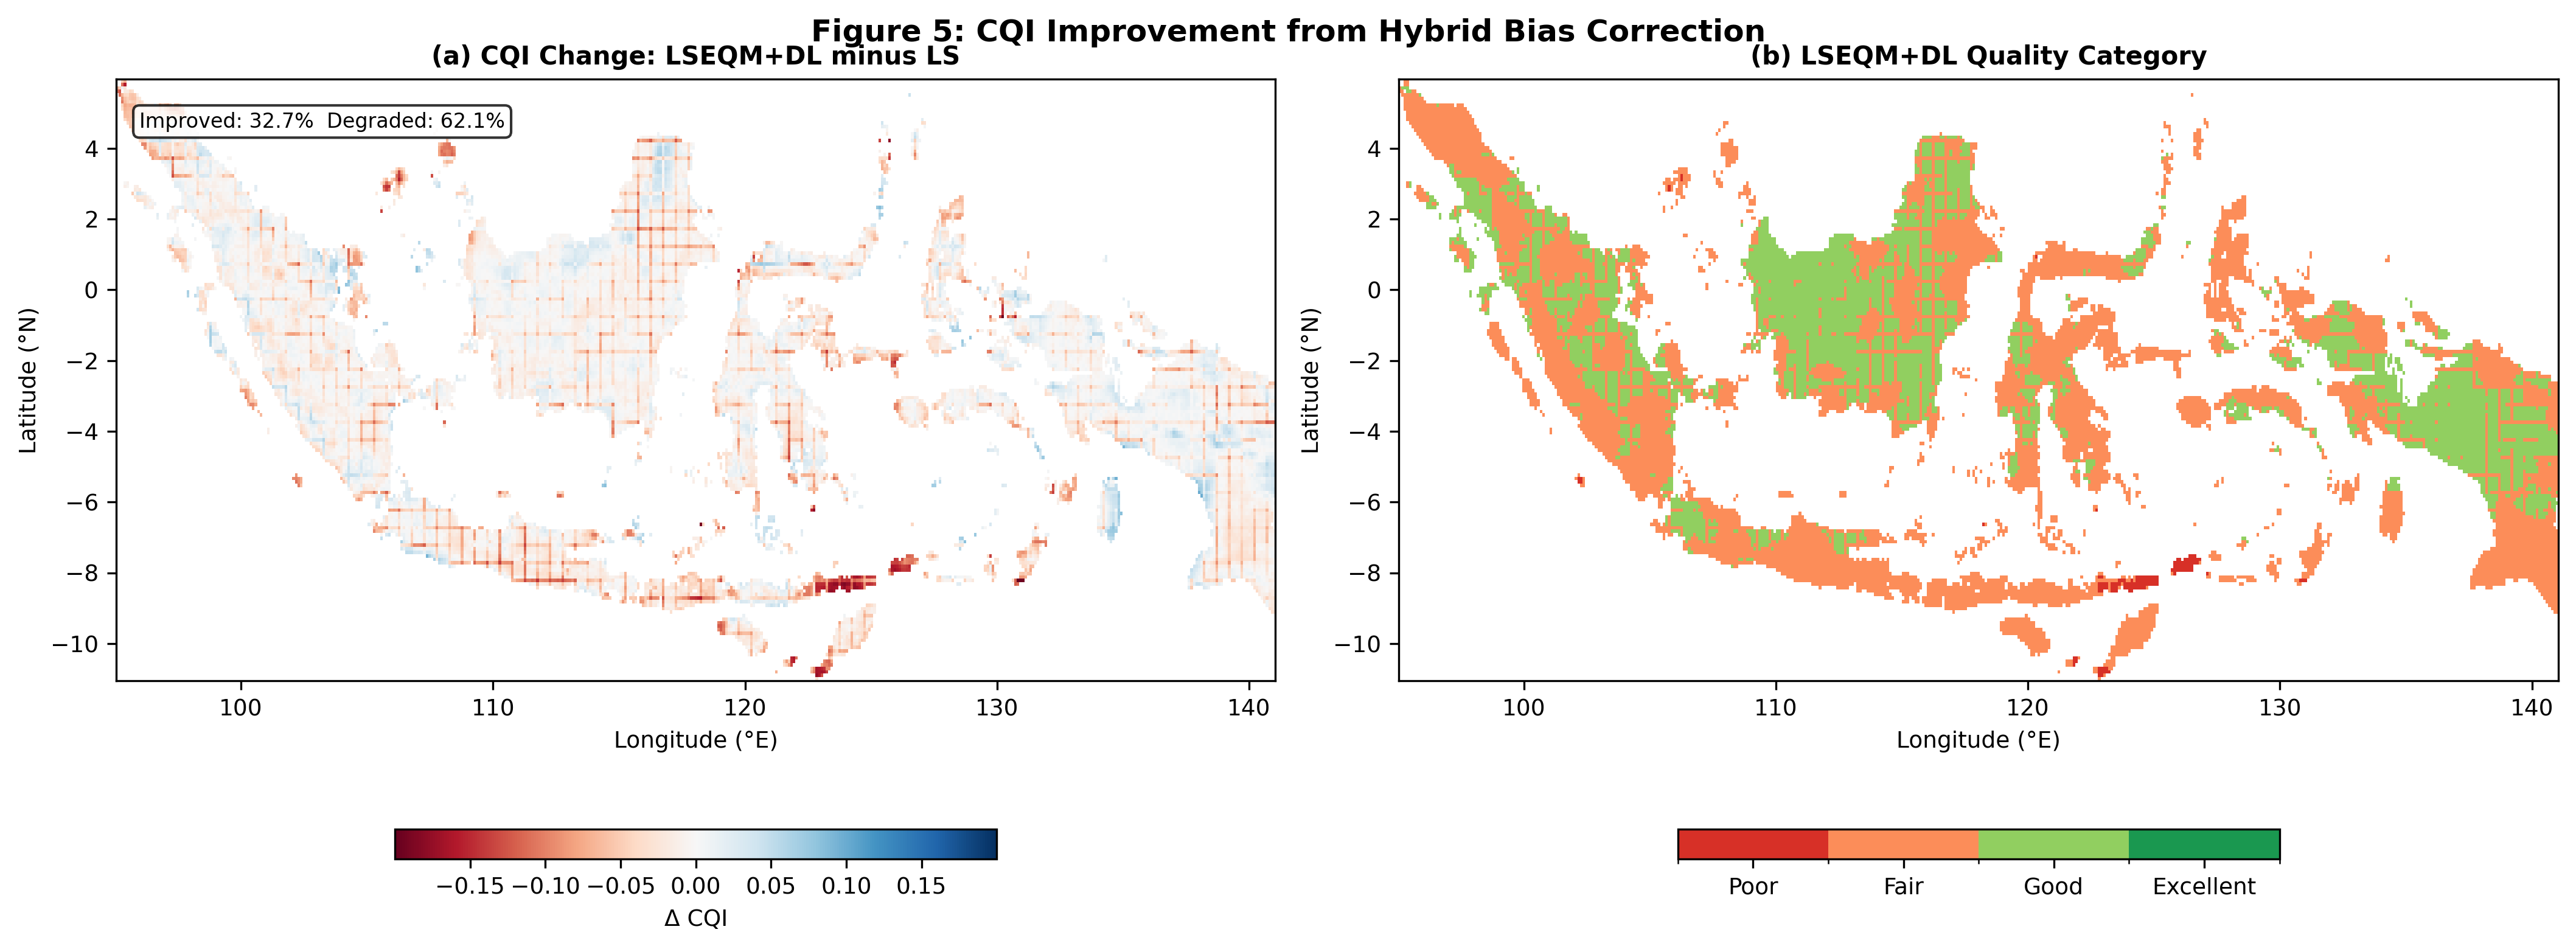

In [10]:
# -- Figure 5: CQI improvement ------------------------------------------------

# CQI difference: LSEQM+DL minus LS
cqi_diff = cqi_maps['lseqmdl'] - cqi_maps['ls']
cqi_dl = cqi_maps['lseqmdl']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel (a): Difference map
ax = axes[0]
vmax_diff = max(abs(np.nanmin(cqi_diff)), abs(np.nanmax(cqi_diff)))
vmax_diff = min(vmax_diff, 0.3)  # cap for readability
im_a = ax.imshow(
    cqi_diff, extent=extent, origin='lower',
    cmap='RdBu', vmin=-vmax_diff, vmax=vmax_diff,
    aspect='auto', interpolation='nearest',
)
ax.set_title('(a) CQI Change: LSEQM+DL minus LS', fontweight='bold')
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
fig.colorbar(im_a, ax=ax, orientation='horizontal', fraction=0.05, pad=0.12,
             label='\u0394 CQI')

# Stats
improved = np.nansum(cqi_diff > 0.001)
degraded = np.nansum(cqi_diff < -0.001)
total_valid = np.nansum(np.isfinite(cqi_diff))
pct_improved = 100.0 * improved / total_valid if total_valid > 0 else 0
pct_degraded = 100.0 * degraded / total_valid if total_valid > 0 else 0
ax.text(0.02, 0.92,
        f'Improved: {pct_improved:.1f}%  Degraded: {pct_degraded:.1f}%',
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel (b): Categorical classification of LSEQM+DL
ax = axes[1]
cat_map = np.full_like(cqi_dl, np.nan)
cat_map[cqi_dl >= 0.8] = 4  # Excellent
cat_map[(cqi_dl >= 0.6) & (cqi_dl < 0.8)] = 3  # Good
cat_map[(cqi_dl >= 0.4) & (cqi_dl < 0.6)] = 2  # Fair
cat_map[(cqi_dl < 0.4) & np.isfinite(cqi_dl)] = 1  # Poor

cat_cmap = mcolors.ListedColormap(['#d73027', '#fc8d59', '#91cf60', '#1a9850'])
cat_norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cat_cmap.N)

im_b = ax.imshow(
    cat_map, extent=extent, origin='lower',
    cmap=cat_cmap, norm=cat_norm,
    aspect='auto', interpolation='nearest',
)
ax.set_title('(b) LSEQM+DL Quality Category', fontweight='bold')
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
cbar_b = fig.colorbar(im_b, ax=ax, orientation='horizontal', fraction=0.05,
                       pad=0.12, ticks=[1, 2, 3, 4])
cbar_b.ax.set_xticklabels(['Poor', 'Fair', 'Good', 'Excellent'])

# Category percentages
for cat_val, cat_name in [(4, 'Excellent'), (3, 'Good'), (2, 'Fair'), (1, 'Poor')]:
    n = np.nansum(cat_map == cat_val)
    pct = 100.0 * n / total_valid if total_valid > 0 else 0
    print(f'{cat_name}: {pct:.1f}% ({n} pixels)')

fig.suptitle('Figure 5: CQI Improvement from Hybrid Bias Correction',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig05_cqi_improvement.png')
plt.show()

## Step 8 — Figure 6: CQI Component Box Plots

Four-panel box plots comparing BSQS, DQS, TQS, and CQI across methods.
Whiskers at 5th and 95th percentiles. DQS is expected to show the largest
improvement.

BSQS LS: median = 0.3256
BSQS LSEQM: median = 0.2978
BSQS LSEQM+DL: median = 0.2986
DQS LS: median = 0.7578
DQS LSEQM: median = 0.7762
DQS LSEQM+DL: median = 0.7771
TQS LS: median = 0.7209
TQS LSEQM: median = 0.7153
TQS LSEQM+DL: median = 0.7160
CQI LS: median = 0.5985
CQI LSEQM: median = 0.5919
CQI LSEQM+DL: median = 0.5930
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig06_component_boxplots.png


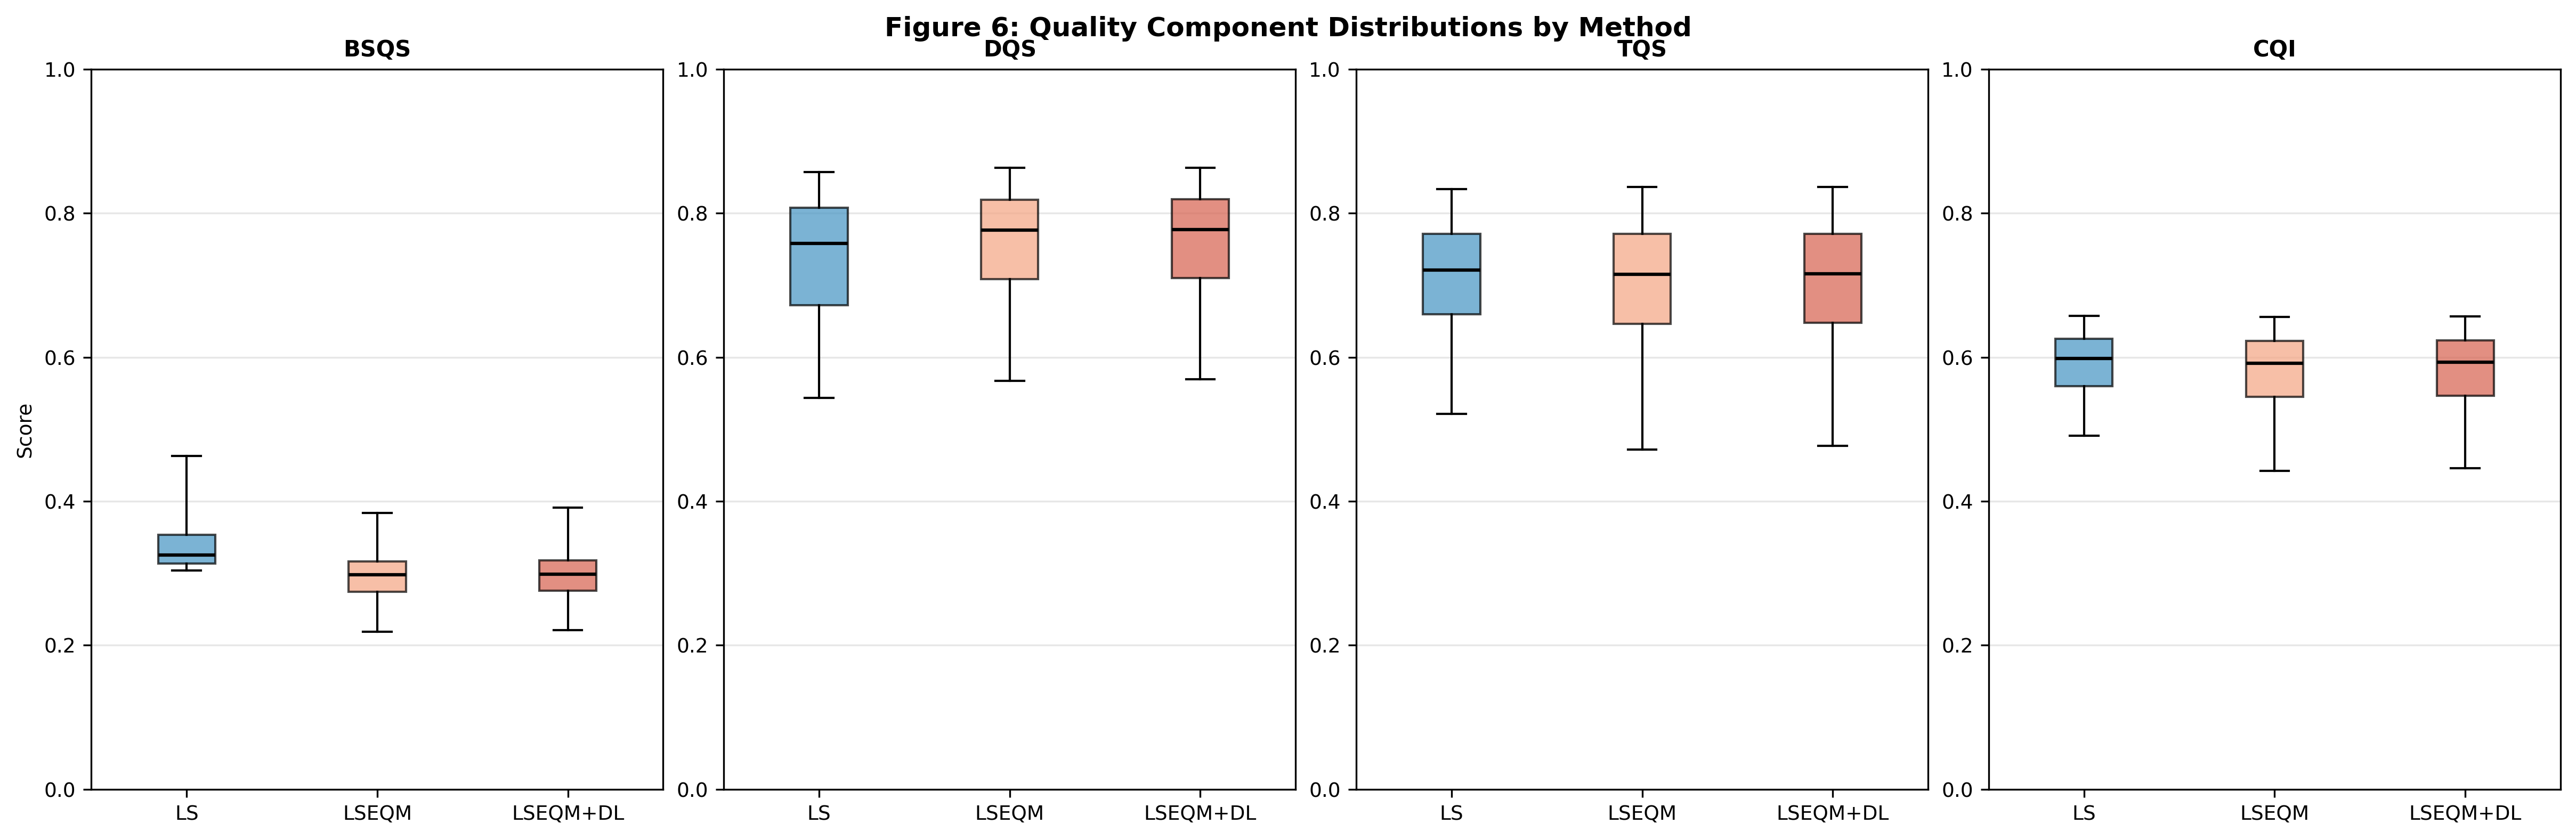

In [11]:
# -- Figure 6: CQI component box plots ----------------------------------------

QUALITY_VARS = [
    ('basic_statistical_quality', 'BSQS'),
    ('distribution_quality', 'DQS'),
    ('temporal_quality', 'TQS'),
    ('continuous_quality', 'CQI'),
]

# Collect all pixel values: {method: {var: 1D array of all pixels x all periods}}
comp_data = {m: {v: [] for v, _ in QUALITY_VARS} for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = quality_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        for var, _ in QUALITY_VARS:
            if var in ds.data_vars:
                vals = ds[var].values.ravel()
                vals = vals[np.isfinite(vals)]
                comp_data[method][var].append(vals)
        ds.close()

# Concatenate
for method in METHODS:
    for var, _ in QUALITY_VARS:
        if comp_data[method][var]:
            comp_data[method][var] = np.concatenate(comp_data[method][var])
        else:
            comp_data[method][var] = np.array([])

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 5), constrained_layout=True)
colors = ['#4393c3', '#f4a582', '#d6604d']  # LS blue, LSEQM orange, DL red

for ax, (var, label) in zip(axes, QUALITY_VARS):
    bp_data = []
    for method in METHODS:
        arr = comp_data[method][var]
        if len(arr) > 0:
            bp_data.append(arr)
        else:
            bp_data.append(np.array([np.nan]))

    bp = ax.boxplot(
        bp_data,
        labels=METHOD_LABELS,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

    # Print medians
    for i, (method, mlabel) in enumerate(zip(METHODS, METHOD_LABELS)):
        med = (np.median(comp_data[method][var])
               if len(comp_data[method][var]) > 0 else np.nan)
        print(f'{label} {mlabel}: median = {med:.4f}')

fig.suptitle('Figure 6: Quality Component Distributions by Method',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig06_component_boxplots.png')
plt.show()

## Step 9 — Table 7 + Figure 7: Station Validation

Independent validation against 171 BMKG weather stations. Table 7 shows
three-pillar metrics computed from station-level data (grand median across
all station x dekad observations).

In [12]:
# -- Table 7: Station validation three-pillar metrics -------------------------

# Direct station metrics
STA_DIRECT = [
    'relative_bias', 'stdev_ratio', 'ks_pvalue',
    'pod', 'csi', 'far',
    'pearson_correlation', 'rmse', 'nse',
]

# Ratio pairs from station CSVs
STA_RATIO_PAIRS = {
    'fpd_ratio': ('fpd_test', 'fpd_ref'),
    'mdwp_ratio': ('mdwp_test', 'mdwp_ref'),
    'p95_ratio': ('p95_test', 'p95_ref'),
    'p99_ratio': ('p99_test', 'p99_ref'),
}

all_sta_keys = STA_DIRECT + list(STA_RATIO_PAIRS.keys())

# Collect all station x dekad observations: {method: {metric: [values]}}
sta_data = {m: {k: [] for k in all_sta_keys} for m in METHODS}
station_counts = {m: 0 for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = station_val_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        station_counts[method] = max(station_counts[method], len(df))

        # Direct metrics
        for v in STA_DIRECT:
            if v in df.columns:
                vals = df[v].dropna().values
                sta_data[method][v].extend(vals.tolist())

        # Ratio metrics
        for ratio_name, (test_col, ref_col) in STA_RATIO_PAIRS.items():
            if test_col in df.columns and ref_col in df.columns:
                mask = df[ref_col].notna() & df[test_col].notna() & (df[ref_col] > 0)
                if mask.any():
                    ratio_vals = (df.loc[mask, test_col] / df.loc[mask, ref_col]).values
                    ratio_vals = ratio_vals[np.isfinite(ratio_vals)]
                    sta_data[method][ratio_name].extend(ratio_vals.tolist())

# Compute grand medians
sta_medians = {}
for method in METHODS:
    sta_medians[method] = {}
    for k in all_sta_keys:
        vals = np.array(sta_data[method][k])
        vals = vals[np.isfinite(vals)]
        sta_medians[method][k] = np.median(vals) if len(vals) > 0 else np.nan

# Print Table 7
print('=' * 72)
print('TABLE 7: Station Validation (171 BMKG stations, grand median)')
print('=' * 72)
print(f'{"Metric":<30} {"Ideal":>6} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
print('-' * 72)

for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    print(f'\n  {pillar_name}')
    print(f'  {"-" * 68}')
    for key, (label, ideal) in pillar_metrics.items():
        vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
        ideal_str = f'{ideal}'
        print(f'  {label:<28} {ideal_str:>6}'
              f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print(f'\n  Temporal Skill (acknowledged limitation)')
print(f'  {"-" * 68}')
for key, (label, ideal) in TEMPORAL_METRICS.items():
    vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
    ideal_str = f'{ideal}'
    print(f'  {label:<28} {ideal_str:>6}'
          f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 72)
for method, mlabel in zip(METHODS, METHOD_LABELS):
    print(f'{mlabel}: up to {station_counts[method]} stations per dekad')

TABLE 7: Station Validation (171 BMKG stations, grand median)
Metric                          Ideal         LS      LSEQM   LSEQM+DL
------------------------------------------------------------------------

  Value Adjustment
  --------------------------------------------------------------------
  Relative Bias                     0    -0.1146    -0.0562    -0.0667
  Std. Dev. Ratio                 1.0     0.7156     0.8901     0.8658

  Distribution Alignment
  --------------------------------------------------------------------
  KS p-value (%)                  100    45.4230    58.0711    55.9966
  Wet-Day Freq. Ratio             1.0     1.2077     1.0423     1.0456
  Mean Wet-Day Precip Ratio       1.0     0.7128     0.8985     0.8821

  Extreme Preservation
  --------------------------------------------------------------------
  Q95 Ratio                       1.0     1.0086     0.9482     0.9492
  Q99 Ratio                       1.0     0.7953     0.9178     0.9131

  Event Detec

Stations with stdev_ratio data: 170
Stdev ratio range: [0.434, 11.728]
Median stdev ratio: 0.916
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig07_station_validation.png


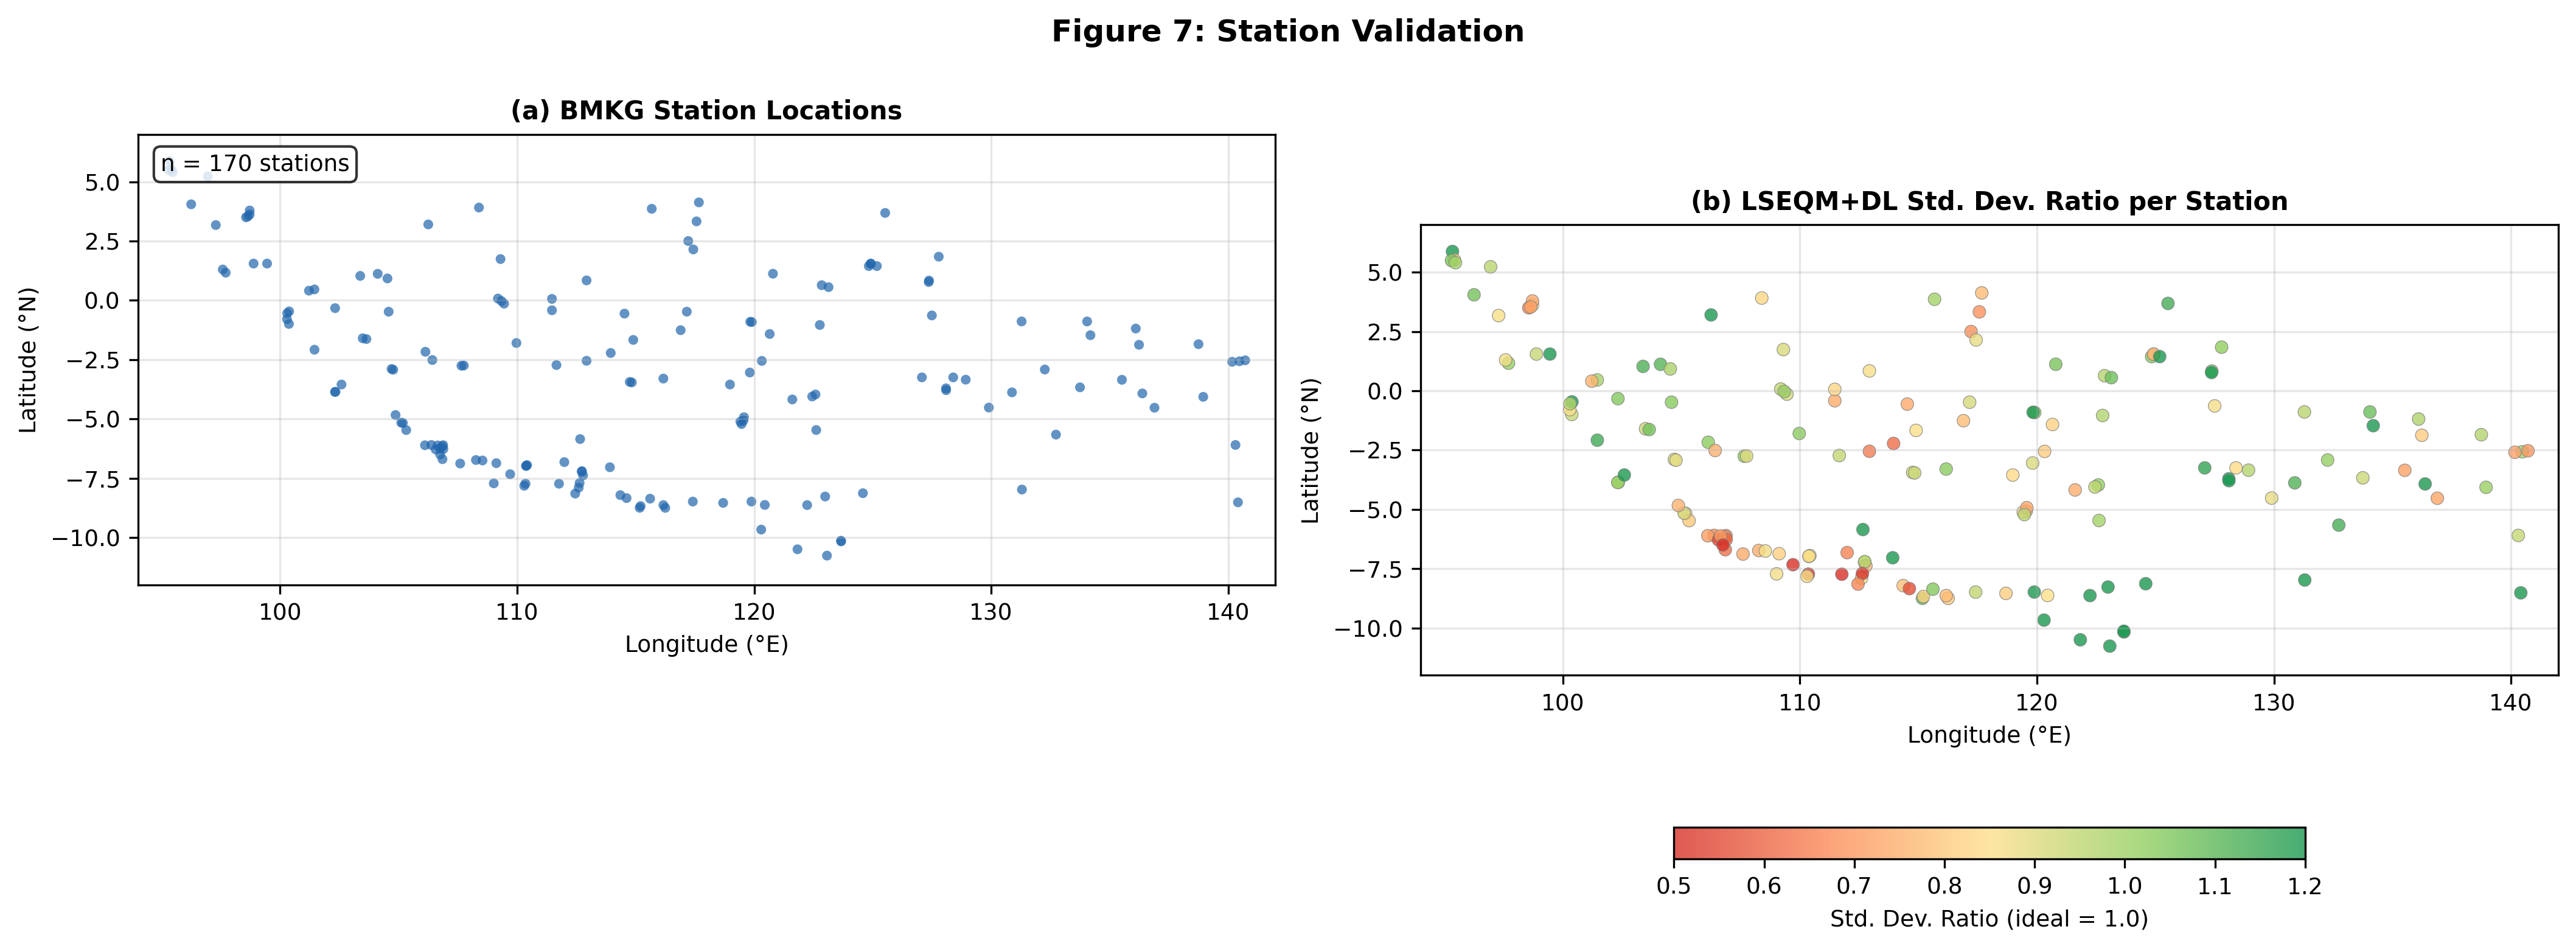

In [13]:
# -- Figure 7: Station validation map -----------------------------------------

# Collect per-station stdev_ratio for LSEQM+DL, averaged across dekads
station_stdev = {}  # station_id -> list of stdev_ratio values
station_info = {}   # station_id -> {lon, lat, name}

for month, dekad in ALL_PERIODS:
    fpath = station_val_path('lseqmdl', month, dekad)
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    for _, row in df.iterrows():
        sid = row['station_id']
        if sid not in station_stdev:
            station_stdev[sid] = []
            station_info[sid] = {
                'lon': row['Lon'],
                'lat': row['Lat'],
                'name': row.get('Station', ''),
            }
        val = row.get('stdev_ratio', np.nan)
        if np.isfinite(val):
            station_stdev[sid].append(val)

# Compute mean stdev_ratio per station
sta_lons = []
sta_lats = []
sta_vals = []
for sid in station_stdev:
    vals = station_stdev[sid]
    if len(vals) > 0:
        sta_lons.append(station_info[sid]['lon'])
        sta_lats.append(station_info[sid]['lat'])
        sta_vals.append(np.mean(vals))

sta_lons = np.array(sta_lons)
sta_lats = np.array(sta_lats)
sta_vals = np.array(sta_vals)

print(f'Stations with stdev_ratio data: {len(sta_vals)}')
print(f'Stdev ratio range: [{sta_vals.min():.3f}, {sta_vals.max():.3f}]')
print(f'Median stdev ratio: {np.median(sta_vals):.3f}')

# Two-panel figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel (a): Station locations
ax = axes[0]
ax.scatter(sta_lons, sta_lats, s=15, c='#2166ac', alpha=0.7, edgecolors='none')
ax.set_xlim(94, 142)
ax.set_ylim(-12, 7)
ax.set_title('(a) BMKG Station Locations', fontweight='bold')
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.text(0.02, 0.92, f'n = {len(sta_vals)} stations',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel (b): Per-station stdev_ratio for LSEQM+DL
ax = axes[1]
# Custom colormap: red (0.5) -> orange (0.7) -> green (1.0)
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'stdev_ratio', ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850'],
    N=256
)
sc = ax.scatter(
    sta_lons, sta_lats,
    c=sta_vals, cmap=cmap_custom,
    vmin=0.5, vmax=1.2,
    s=25, alpha=0.8, edgecolors='grey', linewidths=0.3,
)
ax.set_xlim(94, 142)
ax.set_ylim(-12, 7)
ax.set_title('(b) LSEQM+DL Std. Dev. Ratio per Station', fontweight='bold')
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.05,
                     pad=0.12)
cbar.set_label('Std. Dev. Ratio (ideal = 1.0)')

fig.suptitle('Figure 7: Station Validation',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig07_station_validation.png')
plt.show()

## Step 10 — Figure 8: WMO Multi-Threshold Verification

POD, CSI, and ETS vs precipitation threshold (1, 5, 10, 20, 50, 100, 150 mm).
Lines for each method with IQR shading. Log x-axis for threshold.

Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig08_multi_threshold.png


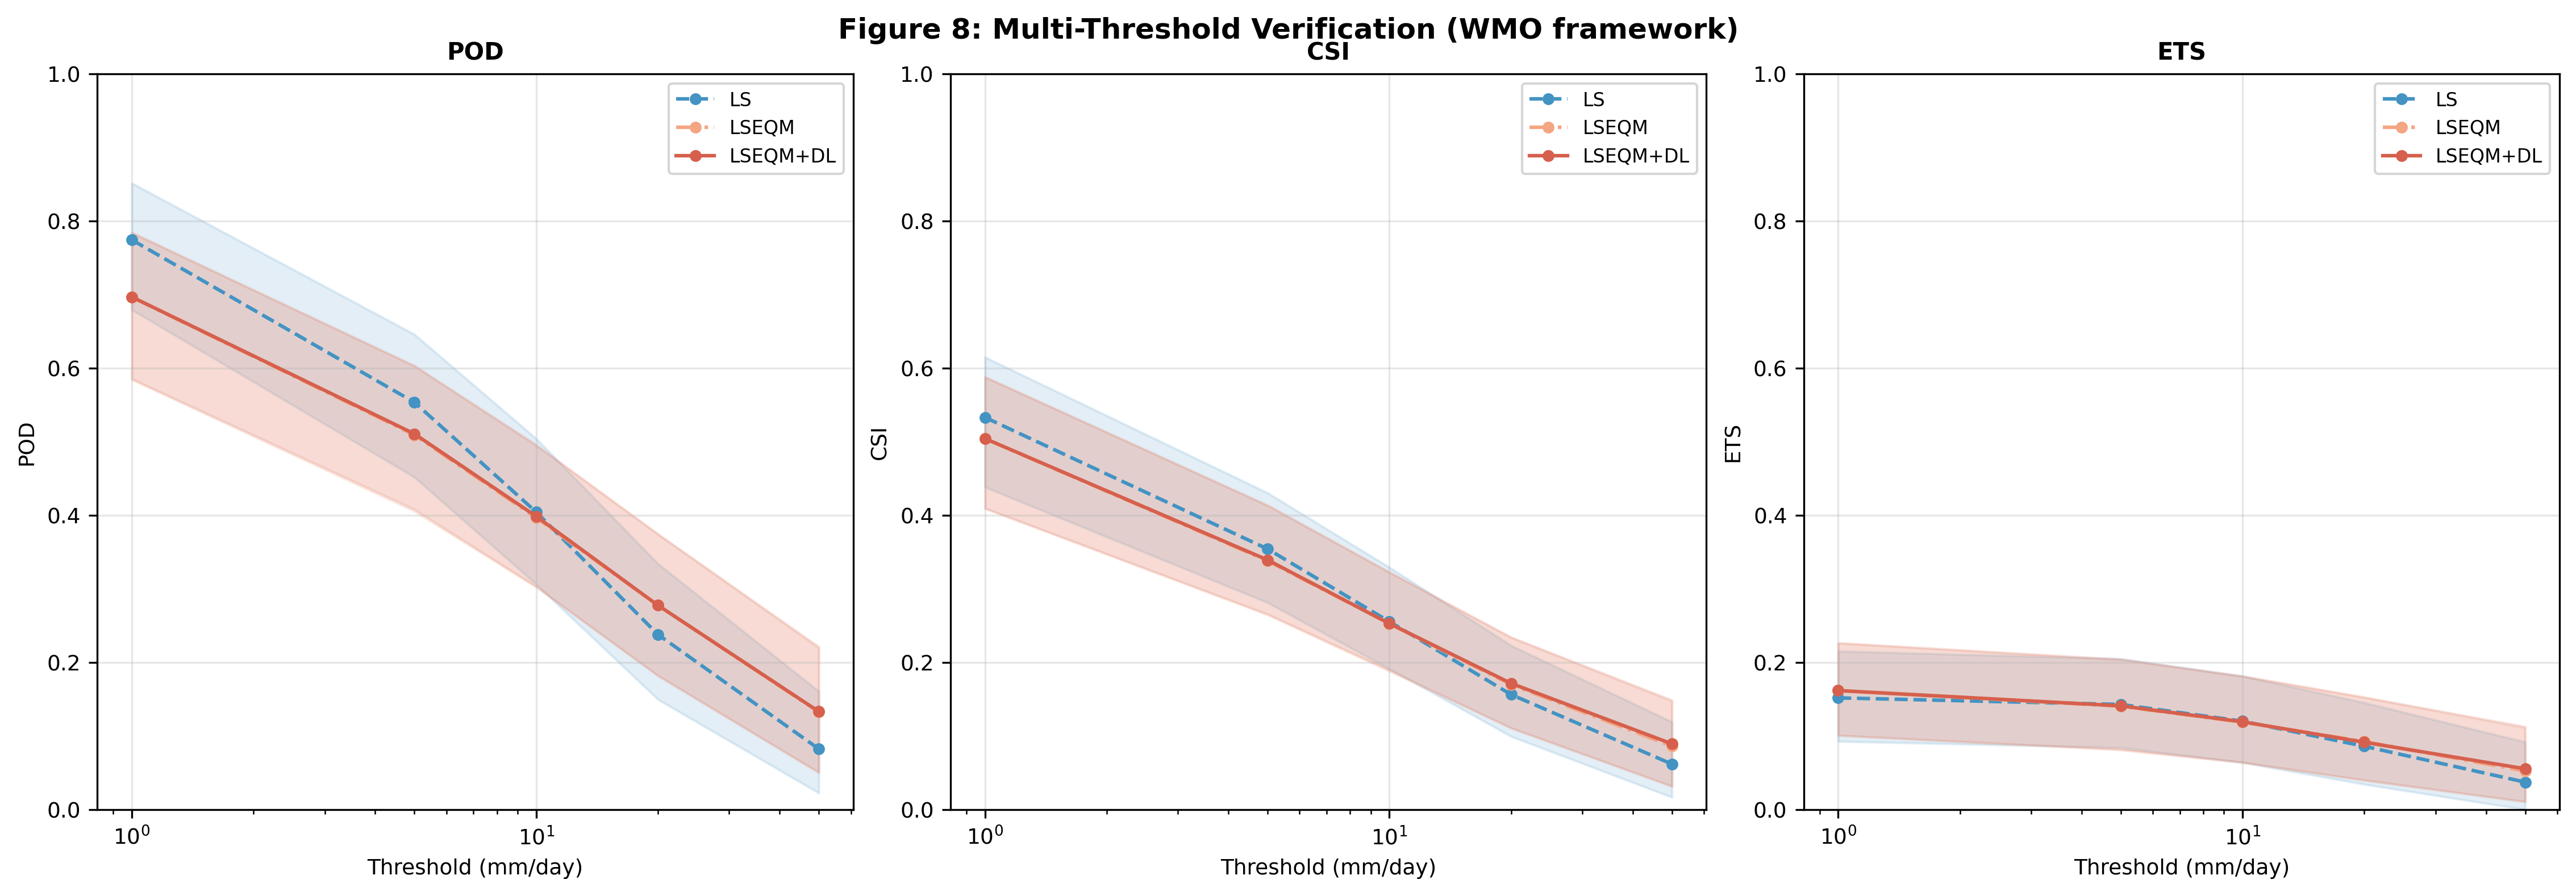

In [14]:
# -- Figure 8: Multi-threshold verification -----------------------------------

# Collect multi-threshold data across all dekads
# Structure: {method: {threshold: {metric: [values across dekads]}}}
mt_metrics = ['pod', 'csi', 'ets']
mt_data = {m: {} for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = multi_threshold_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        for _, row in df.iterrows():
            thr = row['threshold_mm']
            if thr not in mt_data[method]:
                mt_data[method][thr] = {k: {'median': [], 'p25': [], 'p75': []}
                                        for k in mt_metrics}
            for metric in mt_metrics:
                med_col = f'{metric}_median'
                p25_col = f'{metric}_p25'
                p75_col = f'{metric}_p75'
                if med_col in df.columns:
                    mt_data[method][thr][metric]['median'].append(row[med_col])
                if p25_col in df.columns:
                    mt_data[method][thr][metric]['p25'].append(row[p25_col])
                if p75_col in df.columns:
                    mt_data[method][thr][metric]['p75'].append(row[p75_col])

# Plot
metric_labels = {'pod': 'POD', 'csi': 'CSI', 'ets': 'ETS'}
method_colors = {'ls': '#4393c3', 'lseqm': '#f4a582', 'lseqmdl': '#d6604d'}
method_styles = {'ls': '--', 'lseqm': '-.', 'lseqmdl': '-'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, metric in zip(axes, mt_metrics):
    for method, mlabel in zip(METHODS, METHOD_LABELS):
        if not mt_data[method]:
            continue
        thresholds = sorted(mt_data[method].keys())
        med_vals = []
        p25_vals = []
        p75_vals = []
        for thr in thresholds:
            m_list = mt_data[method][thr][metric]['median']
            q25_list = mt_data[method][thr][metric]['p25']
            q75_list = mt_data[method][thr][metric]['p75']
            med_vals.append(np.mean(m_list) if m_list else np.nan)
            p25_vals.append(np.mean(q25_list) if q25_list else np.nan)
            p75_vals.append(np.mean(q75_list) if q75_list else np.nan)

        ax.plot(thresholds, med_vals,
                color=method_colors[method],
                linestyle=method_styles[method],
                marker='o', markersize=4,
                label=mlabel, linewidth=1.5)
        ax.fill_between(thresholds, p25_vals, p75_vals,
                        color=method_colors[method], alpha=0.15)

    ax.set_xscale('log')
    ax.set_title(metric_labels[metric], fontweight='bold')
    ax.set_xlabel('Threshold (mm/day)')
    ax.set_ylabel(metric_labels[metric])
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Figure 8: Multi-Threshold Verification (WMO framework)',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig08_multi_threshold.png')
plt.show()

## Step 11 — Figure 9: Confidence Mask Analysis

Panel (a): Confidence mask spatial map.
Panel (b): CQI improvement (LSEQM+DL minus LSEQM) binned by confidence quintile.

Confidence mask: median=0.002, mean=0.028
  Zero confidence: 20353 pixels (25.8%)
  Full confidence: 0 pixels (0.0%)
  Confidence 0-0.2: n=18329, median dCQI=0.0005
  Confidence 0.2-0.4: n=930, median dCQI=0.0058
  Confidence 0.4-0.6: n=102, median dCQI=0.0050
  Confidence 0.6-0.8: n=32, median dCQI=0.0083
  Confidence 0.8-1.0: n=0
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig09_confidence_mask.png


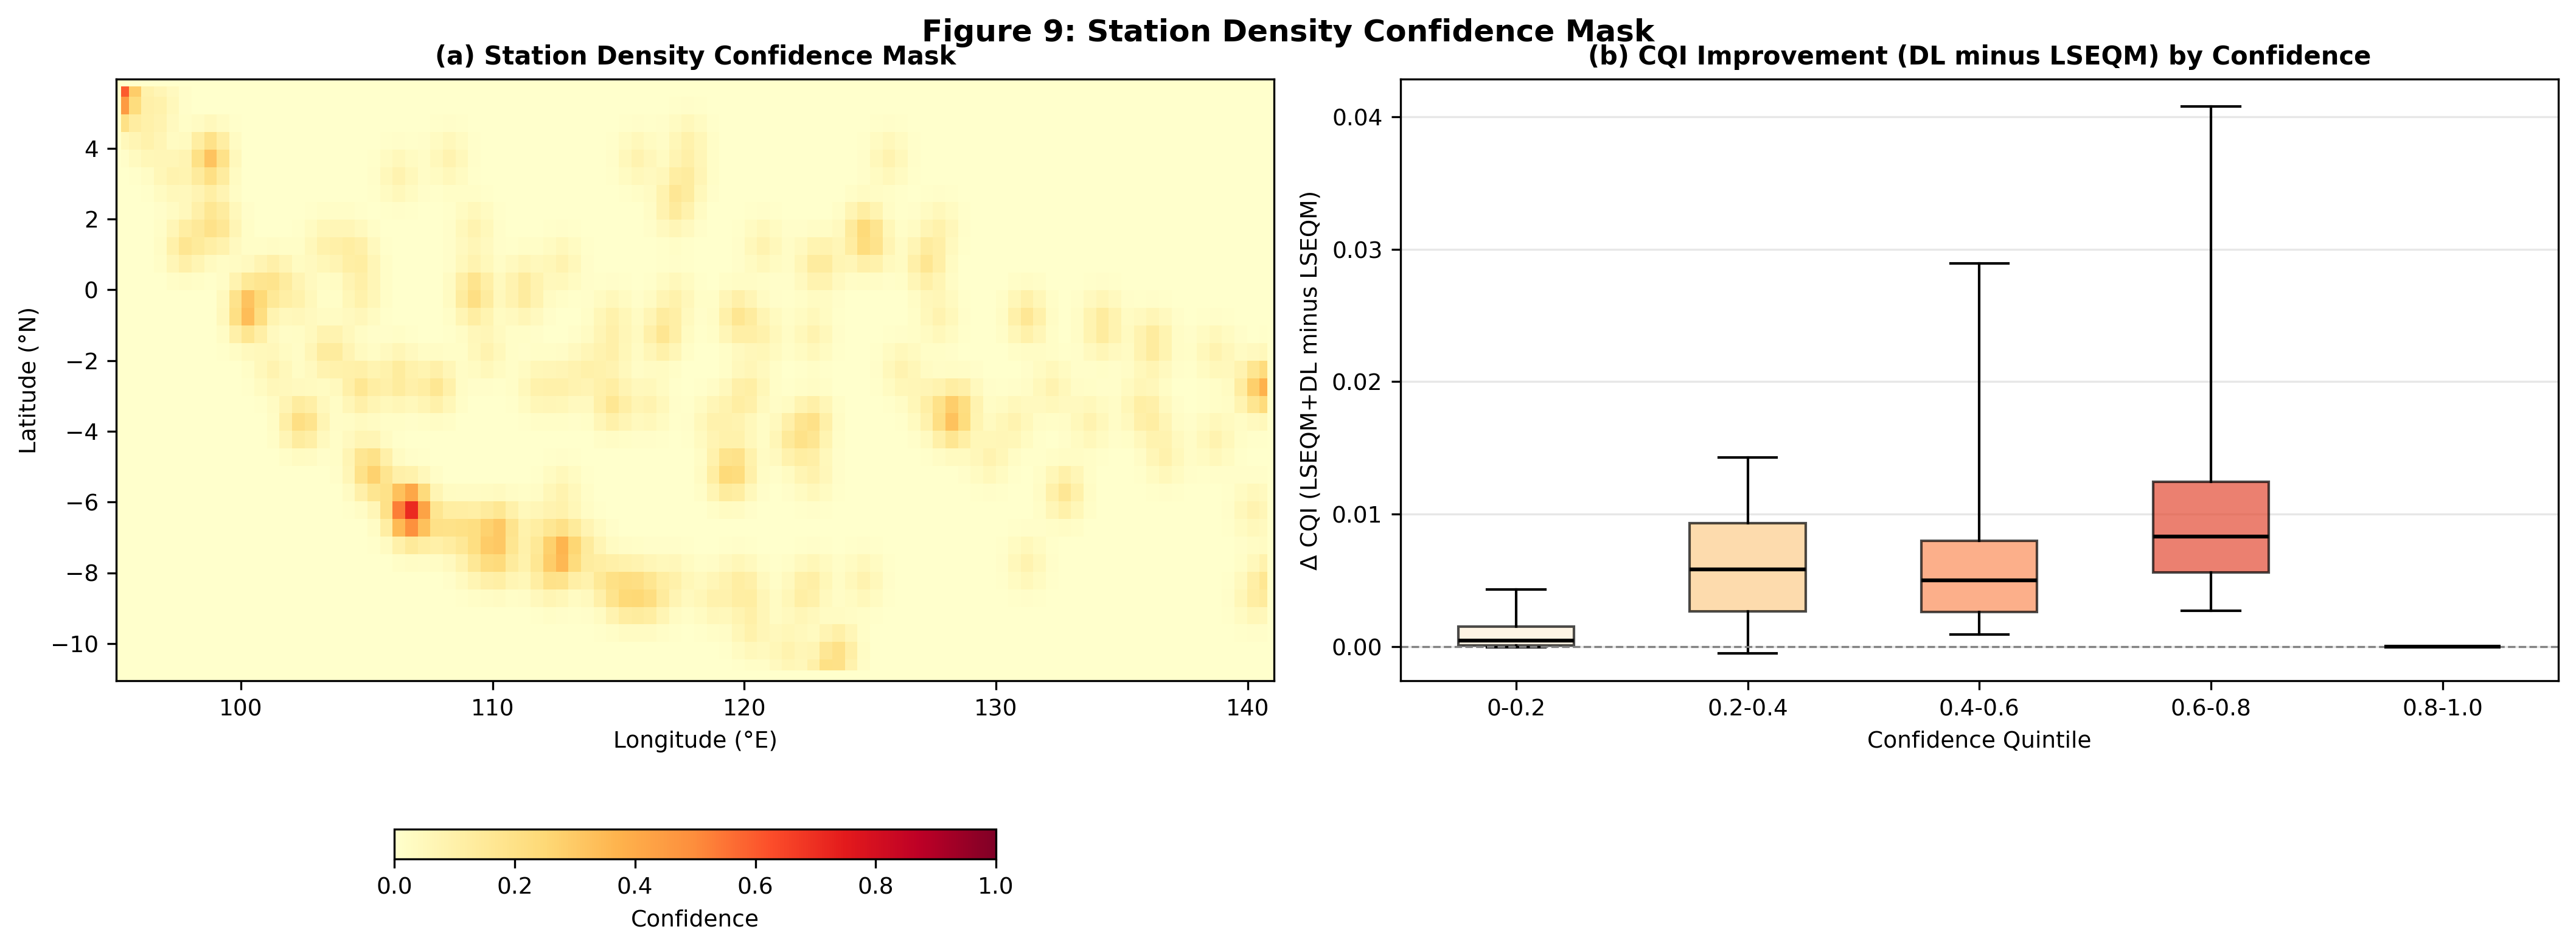

In [15]:
# -- Figure 9: Confidence mask analysis ----------------------------------------

# Load confidence mask
conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
conf_ds = xr.open_dataset(conf_mask_path, decode_timedelta=False)
conf_arr = conf_ds['confidence'].values
conf_lat = conf_ds['lat'].values
conf_lon = conf_ds['lon'].values
conf_ds.close()

# CQI improvement: LSEQM+DL minus LSEQM
cqi_lseqm = cqi_maps.get('lseqm', None)
cqi_lseqmdl = cqi_maps.get('lseqmdl', None)
cqi_improvement = None
if cqi_lseqm is not None and cqi_lseqmdl is not None:
    cqi_improvement = cqi_lseqmdl - cqi_lseqm

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel (a): Confidence mask map
ax = axes[0]
conf_extent = [conf_lon.min(), conf_lon.max(),
               conf_lat.min(), conf_lat.max()]
im_a = ax.imshow(
    conf_arr, extent=conf_extent, origin='lower',
    cmap='YlOrRd', vmin=0, vmax=1,
    aspect='auto', interpolation='nearest',
)
ax.set_title('(a) Station Density Confidence Mask', fontweight='bold')
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
cbar_a = fig.colorbar(im_a, ax=ax, orientation='horizontal',
                       fraction=0.05, pad=0.12)
cbar_a.set_label('Confidence')

# Stats
valid_conf = conf_arr[np.isfinite(conf_arr)]
print(f'Confidence mask: median={np.median(valid_conf):.3f}, '
      f'mean={np.mean(valid_conf):.3f}')
print(f'  Zero confidence: {np.sum(valid_conf == 0)} pixels '
      f'({100 * np.sum(valid_conf == 0) / len(valid_conf):.1f}%)')
print(f'  Full confidence: {np.sum(valid_conf >= 1.0)} pixels '
      f'({100 * np.sum(valid_conf >= 1.0) / len(valid_conf):.1f}%)')

# Panel (b): CQI improvement by confidence quintile
ax = axes[1]
if cqi_improvement is not None:
    # Define confidence bins (quintiles)
    conf_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    bp_data_bins = []

    for i in range(len(conf_bins) - 1):
        lo, hi = conf_bins[i], conf_bins[i + 1]
        if i == len(conf_bins) - 2:  # last bin includes upper bound
            mask_bin = ((conf_arr >= lo) & (conf_arr <= hi)
                        & np.isfinite(cqi_improvement))
        else:
            mask_bin = ((conf_arr >= lo) & (conf_arr < hi)
                        & np.isfinite(cqi_improvement))
        vals = cqi_improvement[mask_bin]
        bp_data_bins.append(vals if len(vals) > 0 else np.array([0.0]))
        if len(vals) > 0:
            print(f'  Confidence {bin_labels[i]}: n={len(vals)}, '
                  f'median dCQI={np.median(vals):.4f}')
        else:
            print(f'  Confidence {bin_labels[i]}: n=0')

    bp = ax.boxplot(
        bp_data_bins,
        labels=bin_labels,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
    )
    colors_q = ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000']
    for patch, c in zip(bp['boxes'], colors_q):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title('(b) CQI Improvement (DL minus LSEQM) by Confidence',
                 fontweight='bold')
    ax.set_xlabel('Confidence Quintile')
    ax.set_ylabel('\u0394 CQI (LSEQM+DL minus LSEQM)')
    ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'CQI data not available', transform=ax.transAxes,
            ha='center', va='center')

fig.suptitle('Figure 9: Station Density Confidence Mask',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig09_confidence_mask.png')
plt.show()

## Step 12 — Supplementary: Wet vs Dry Season

Split 36 dekads into wet (Oct-Mar) and dry (Apr-Sep) seasons. Compare
three-pillar metrics for each season.

In [16]:
# -- Supplementary: Wet vs Dry season comparison ------------------------------

season_periods = {
    'Wet (Oct-Mar)': [(m, d) for m, d in ALL_PERIODS if m in WET_MONTHS],
    'Dry (Apr-Sep)': [(m, d) for m, d in ALL_PERIODS if m in DRY_MONTHS],
}

all_keys = DIRECT_VARS + list(RATIO_PAIRS.keys())
seasonal_means = {}  # {season: {method: {metric: mean}}}

for season_name, periods in season_periods.items():
    seasonal_means[season_name] = {}
    for method in METHODS:
        accum = {k: [] for k in all_keys}
        for month, dekad in periods:
            fpath = metrics_path(method, month, dekad)
            if not os.path.exists(fpath):
                continue
            ds = xr.open_dataset(fpath, decode_timedelta=False)
            medians = compute_spatial_medians(ds, DIRECT_VARS)
            ratio_m = compute_ratio_medians(ds, RATIO_PAIRS)
            medians.update(ratio_m)
            for k in all_keys:
                val = medians.get(k, np.nan)
                if np.isfinite(val):
                    accum[k].append(val)
            ds.close()

        seasonal_means[season_name][method] = {
            k: np.mean(accum[k]) if accum[k] else np.nan
            for k in all_keys
        }

# Print seasonal comparison
print('=' * 80)
print('SUPPLEMENTARY: Wet vs Dry Season Comparison')
print('=' * 80)

display_metrics = [
    ('relative_bias', 'Relative Bias'),
    ('stdev_ratio', 'Std. Dev. Ratio'),
    ('ks_pvalue', 'KS p-value (%)'),
    ('fpd_ratio', 'Wet-Day Freq. Ratio'),
    ('p95_ratio', 'Q95 Ratio'),
    ('p99_ratio', 'Q99 Ratio'),
    ('pod', 'POD'),
    ('csi', 'CSI'),
    ('pearson_correlation', 'Pearson Corr'),
    ('rmse', 'RMSE (mm/day)'),
]

for season_name in season_periods:
    n_periods = len(season_periods[season_name])
    print(f'\n  {season_name} ({n_periods} dekads)')
    print(f'  {"Metric":<25} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
    print(f'  {"-" * 57}')
    for key, label in display_metrics:
        vals = [seasonal_means[season_name][m].get(key, np.nan) for m in METHODS]
        print(f'  {label:<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 80)

SUPPLEMENTARY: Wet vs Dry Season Comparison

  Wet (Oct-Mar) (18 dekads)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0001    -0.0053    -0.0094
  Std. Dev. Ratio               0.9569     1.0104     1.0015
  KS p-value (%)               53.1001    56.4375    55.7627
  Wet-Day Freq. Ratio           1.0532     0.9815     0.9816
  Q95 Ratio                     1.0225     0.9772     0.9772
  Q99 Ratio                     0.9567     1.0157     1.0121
  POD                           0.8016     0.7505     0.7505
  CSI                           0.6245     0.6026     0.6026
  Pearson Corr                  0.3242     0.3279     0.3301
  RMSE (mm/day)                14.0454    14.0585    13.9667

  Dry (Apr-Sep) (18 dekads)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                -0.0000    -0.0

## Step 13 — Supplementary: Per-Month Temporal Stability

Plot key metrics across the 12 months to check for temporal stability of
corrections.

Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig_supp_temporal_stability.png


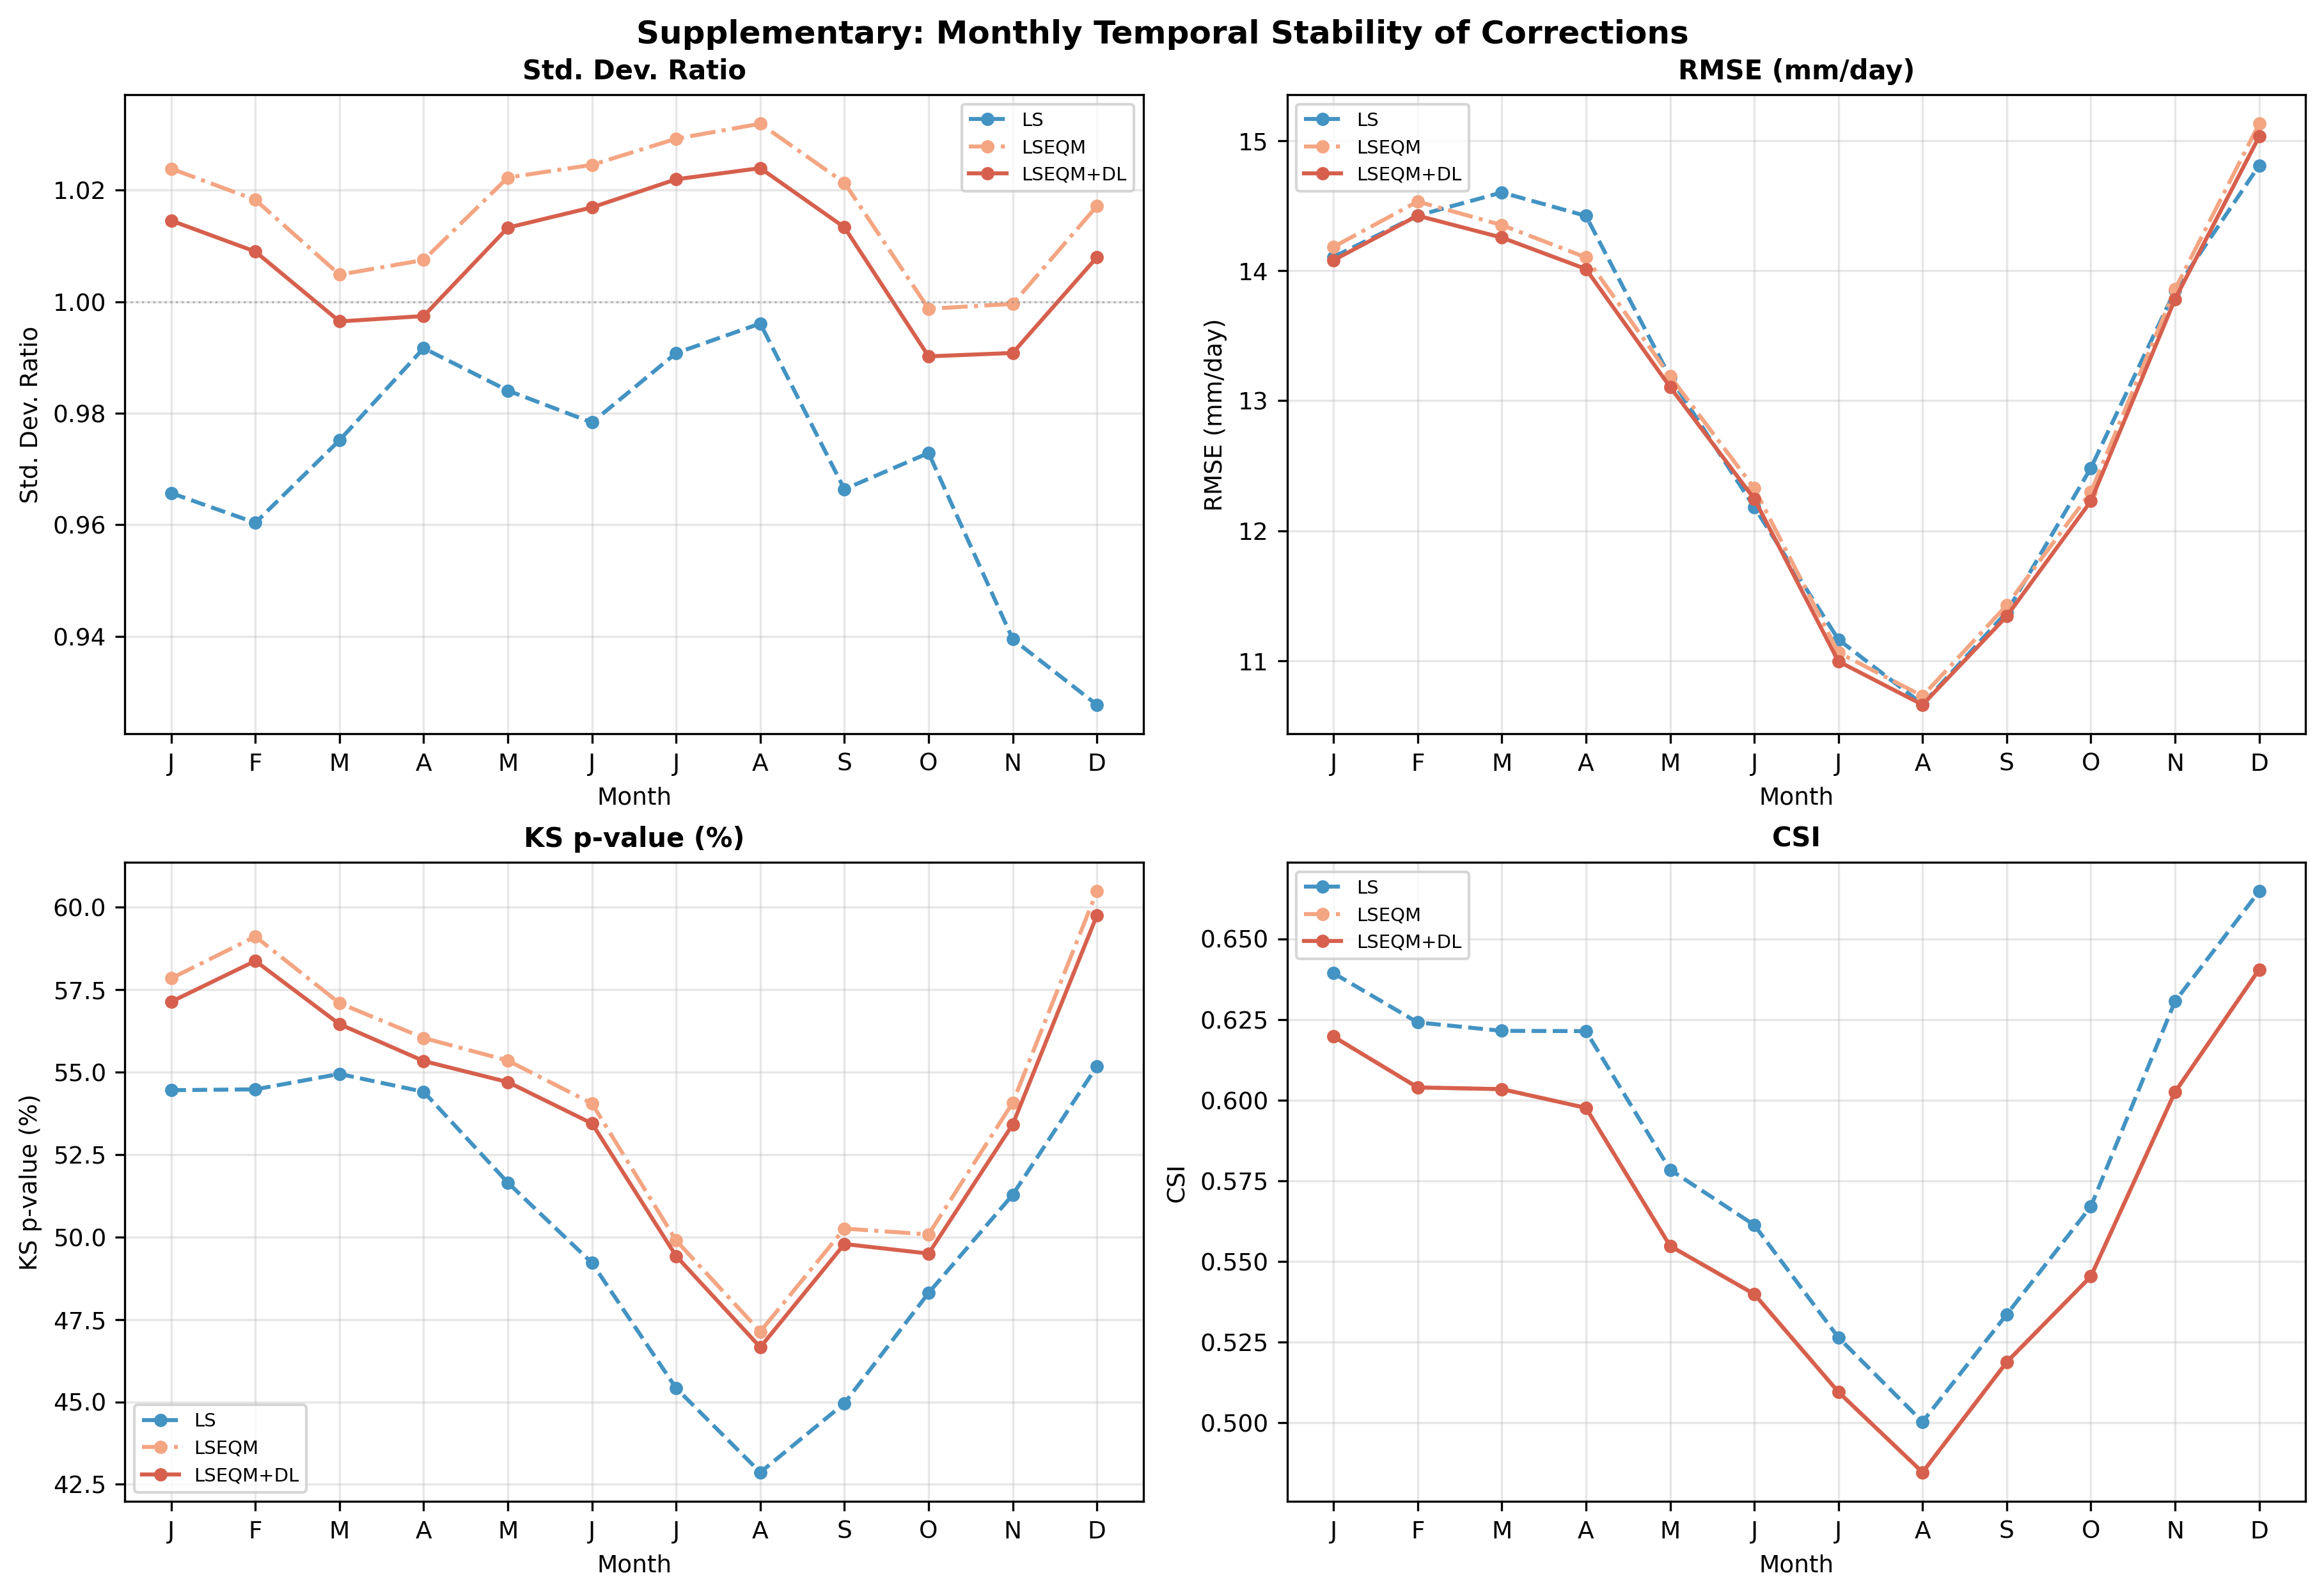

In [17]:
# -- Supplementary: Temporal stability ----------------------------------------

# Aggregate metrics by month (average across 3 dekads within each month)
monthly_metrics = {m: {k: {mo: [] for mo in range(1, 13)}
                       for k in ['stdev_ratio', 'rmse', 'ks_pvalue', 'csi']}
                   for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        medians = compute_spatial_medians(
            ds, ['stdev_ratio', 'rmse', 'ks_pvalue', 'csi'])
        for k in medians:
            if np.isfinite(medians[k]):
                monthly_metrics[method][k][month].append(medians[k])
        ds.close()

# Plot
plot_vars = [
    ('stdev_ratio', 'Std. Dev. Ratio', 1.0),
    ('rmse', 'RMSE (mm/day)', None),
    ('ks_pvalue', 'KS p-value (%)', None),
    ('csi', 'CSI', None),
]

method_colors = {'ls': '#4393c3', 'lseqm': '#f4a582', 'lseqmdl': '#d6604d'}
method_styles = {'ls': '--', 'lseqm': '-.', 'lseqmdl': '-'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for ax, (var, label, ideal) in zip(axes.ravel(), plot_vars):
    for method, mlabel in zip(METHODS, METHOD_LABELS):
        months_x = list(range(1, 13))
        vals_y = []
        for mo in months_x:
            v_list = monthly_metrics[method][var][mo]
            vals_y.append(np.mean(v_list) if v_list else np.nan)
        ax.plot(months_x, vals_y,
                color=method_colors[method],
                linestyle=method_styles[method],
                marker='o', markersize=4,
                label=mlabel, linewidth=1.5)

    if ideal is not None:
        ax.axhline(ideal, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel('Month')
    ax.set_ylabel(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Supplementary: Monthly Temporal Stability of Corrections',
             fontsize=12, fontweight='bold', y=1.02)

save_fig(fig, 'fig_supp_temporal_stability.png')
plt.show()

## Step 14 — Summary: Paper Fill-In Values

Consolidated summary of all numerical values needed for the paper text,
organized by section.

In [18]:
# -- Summary: Paper fill-in values --------------------------------------------

def fmt(val, decimals=4):
    """Format a value for display."""
    if np.isfinite(val):
        return f'{val:.{decimals}f}'
    return 'N/A'


print('=' * 80)
print('PAPER FILL-IN VALUES')
print('=' * 80)

# -- Abstract fill-in ---------------------------------------------------------
print('\n--- ABSTRACT ---')
t4 = table4_means
print(f'Domain-wide Relative Bias:  LS={fmt(t4["ls"]["relative_bias"])}, '
      f'LSEQM={fmt(t4["lseqm"]["relative_bias"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["relative_bias"])}')
print(f'Domain-wide Stdev Ratio:    LS={fmt(t4["ls"]["stdev_ratio"])}, '
      f'LSEQM={fmt(t4["lseqm"]["stdev_ratio"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["stdev_ratio"])}')
print(f'Domain-wide KS p-value (%): LS={fmt(t4["ls"]["ks_pvalue"], 2)}, '
      f'LSEQM={fmt(t4["lseqm"]["ks_pvalue"], 2)}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["ks_pvalue"], 2)}')
print(f'Domain-wide Q99 Ratio:      LS={fmt(t4["ls"]["p99_ratio"])}, '
      f'LSEQM={fmt(t4["lseqm"]["p99_ratio"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["p99_ratio"])}')
print(f'Station RB:                 LS={fmt(sta_medians["ls"]["relative_bias"])}, '
      f'LSEQM={fmt(sta_medians["lseqm"]["relative_bias"])}, '
      f'LSEQM+DL={fmt(sta_medians["lseqmdl"]["relative_bias"])}')
print(f'Station Stdev Ratio:        LS={fmt(sta_medians["ls"]["stdev_ratio"])}, '
      f'LSEQM={fmt(sta_medians["lseqm"]["stdev_ratio"])}, '
      f'LSEQM+DL={fmt(sta_medians["lseqmdl"]["stdev_ratio"])}')

# -- Table 4 fill-in ----------------------------------------------------------
print('\n--- TABLE 4 (Domain-Wide) ---')
all_t4_metrics_flat = {}
for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    for key, (label, ideal) in pillar_metrics.items():
        all_t4_metrics_flat[key] = label
for key, (label, ideal) in TEMPORAL_METRICS.items():
    all_t4_metrics_flat[key] = label

for key, label in all_t4_metrics_flat.items():
    vals = [t4[m].get(key, np.nan) for m in METHODS]
    print(f'{label:<28} LS={fmt(vals[0])}  LSEQM={fmt(vals[1])}  LSEQM+DL={fmt(vals[2])}')

# -- Table 5 fill-in ----------------------------------------------------------
print('\n--- TABLE 5 (Percentile Fidelity) ---')
for p, plabel in zip(PCTL_VARS, PCTL_LABELS):
    ref_val = (np.mean(table5_data['ls'][p]['ref'])
               if table5_data['ls'][p]['ref'] else np.nan)
    test_vals = []
    for method in METHODS:
        tv = (np.mean(table5_data[method][p]['test'])
              if table5_data[method][p]['test'] else np.nan)
        test_vals.append(tv)
    print(f'{plabel}: Ref={fmt(ref_val, 2)}  '
          f'LS={fmt(test_vals[0], 2)}  '
          f'LSEQM={fmt(test_vals[1], 2)}  '
          f'LSEQM+DL={fmt(test_vals[2], 2)}')

# -- Table 7 fill-in ----------------------------------------------------------
print('\n--- TABLE 7 (Station Validation) ---')
for key, label in all_t4_metrics_flat.items():
    vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
    print(f'{label:<28} LS={fmt(vals[0])}  LSEQM={fmt(vals[1])}  LSEQM+DL={fmt(vals[2])}')

# -- CQI fill-in --------------------------------------------------------------
print('\n--- CQI VALUES ---')
for method, mlabel in zip(METHODS, METHOD_LABELS):
    if method in cqi_maps:
        med = np.nanmedian(cqi_maps[method])
        mean_val = np.nanmean(cqi_maps[method])
        print(f'{mlabel}: median CQI={fmt(med)}, mean CQI={fmt(mean_val)}')

# -- Section narrative fill-in -------------------------------------------------
print('\n--- SECTION NARRATIVE VALUES ---')

# KS improvement
ks_ls = t4['ls']['ks_pvalue']
ks_lseqm = t4['lseqm']['ks_pvalue']
if np.isfinite(ks_ls) and np.isfinite(ks_lseqm) and ks_ls > 0:
    ks_pct_change = 100.0 * (ks_lseqm - ks_ls) / ks_ls
    print(f'KS p-value improvement (LS->LSEQM): {ks_pct_change:+.1f}%')

# Q99 improvement
q99_ls = t4['ls']['p99_ratio']
q99_lseqm = t4['lseqm']['p99_ratio']
print(f'Q99 Ratio: LS={fmt(q99_ls)} -> LSEQM={fmt(q99_lseqm)} '
      f'(closer to 1.0 by {abs(1.0 - q99_lseqm) - abs(1.0 - q99_ls):.4f})')

# RMSE comparison
rmse_ls = t4['ls']['rmse']
rmse_dl = t4['lseqmdl']['rmse']
if np.isfinite(rmse_ls) and np.isfinite(rmse_dl) and rmse_ls > 0:
    rmse_pct = 100.0 * (rmse_dl - rmse_ls) / rmse_ls
    print(f'RMSE change (LS->LSEQM+DL): {rmse_pct:+.2f}%')

# Station stdev improvement
sta_sd_ls = sta_medians['ls']['stdev_ratio']
sta_sd_lseqm = sta_medians['lseqm']['stdev_ratio']
sta_sd_dl = sta_medians['lseqmdl']['stdev_ratio']
print(f'Station Stdev Ratio: LS={fmt(sta_sd_ls)} -> LSEQM={fmt(sta_sd_lseqm)} '
      f'-> LSEQM+DL={fmt(sta_sd_dl)}')

# Station KS improvement
sta_ks_ls = sta_medians['ls']['ks_pvalue']
sta_ks_lseqm = sta_medians['lseqm']['ks_pvalue']
if np.isfinite(sta_ks_ls) and np.isfinite(sta_ks_lseqm):
    print(f'Station KS p-value: LS={fmt(sta_ks_ls, 2)}% -> '
          f'LSEQM={fmt(sta_ks_lseqm, 2)}% '
          f'(+{sta_ks_lseqm - sta_ks_ls:.2f} pp)')

print('\n' + '=' * 80)
print('All paper fill-in values generated successfully.')

PAPER FILL-IN VALUES

--- ABSTRACT ---
Domain-wide Relative Bias:  LS=0.0000, LSEQM=-0.0089, LSEQM+DL=-0.0125
Domain-wide Stdev Ratio:    LS=0.9707, LSEQM=1.0166, LSEQM+DL=1.0080
Domain-wide KS p-value (%): LS=50.59, LSEQM=54.28, LSEQM+DL=53.66
Domain-wide Q99 Ratio:      LS=0.9612, LSEQM=1.0104, LSEQM+DL=1.0090
Station RB:                 LS=-0.1146, LSEQM=-0.0562, LSEQM+DL=-0.0667
Station Stdev Ratio:        LS=0.7156, LSEQM=0.8901, LSEQM+DL=0.8658

--- TABLE 4 (Domain-Wide) ---
Relative Bias                LS=0.0000  LSEQM=-0.0089  LSEQM+DL=-0.0125
Std. Dev. Ratio              LS=0.9707  LSEQM=1.0166  LSEQM+DL=1.0080
KS p-value (%)               LS=50.5905  LSEQM=54.2755  LSEQM+DL=53.6575
Wet-Day Freq. Ratio          LS=1.0397  LSEQM=0.9630  LSEQM+DL=0.9633
Mean Wet-Day Precip Ratio    LS=0.9611  LSEQM=1.0417  LSEQM+DL=1.0361
Q95 Ratio                    LS=1.0205  LSEQM=0.9530  LSEQM+DL=0.9530
Q99 Ratio                    LS=0.9612  LSEQM=1.0104  LSEQM+DL=1.0090
POD                